In [1]:
import json
import re
import random
import spacy
from pathlib import Path
import math
from openai import OpenAI
import numpy as np
from collections import Counter
import statistics
from statistics import mean, median, stdev
import matplotlib.pyplot as plt
from scipy.stats import spearmanr, ks_2samp
import nltk
from nltk.corpus import cmudict


nltk.download("cmudict")
cmu_dict = cmudict.dict()


INPUT_DIR = Path("English")
OUTPUT_DIR = Path("human corpus")
HUMAN_CORPUS_DIR = Path("human corpus sample")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
HUMAN_CORPUS_DIR.mkdir(parents=True, exist_ok=True)

AI_OUTPUT_DIR = Path("AI output")
AI_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
AI_CORPUS_DIR = Path("AI corpus")
AI_CORPUS_DIR.mkdir(parents=True, exist_ok=True)
MODEL = "gpt-5.4"
MODEL_LABEL = "GPT 5 4"

RESULTS_DIR = Path("results")
RESULTS_DIR.mkdir(exist_ok=True)


SAMPLE_SIZE = 4
TARGET_TOKENS = 1500
CHUNK_LIMIT = 200000

OUTPUT_PATH = Path("marker_analysis.json")

nlp = spacy.load("en_core_web_sm")
nlp.max_length = CHUNK_LIMIT + 1000

random.seed(7)


[nltk_data] Downloading package cmudict to /home/lilek/nltk_data...
[nltk_data]   Package cmudict is already up-to-date!


##### Corpus preprocessing and file handling

In [ ]:
def tokenize(text):
    text = re.sub(r"\s+", " ", text).strip()
    text = (
    text.replace("’", "'")
    .replace("´", "'")
    .replace("—", " ")
    .replace("--", " ")
    .replace("_", " "))

    tokens = text.split()
    tokens_strip = []

    for token in tokens:
        token = re.sub(r"^\W+|\W+$", "", token.lower())
        if token:
            tokens_strip.append(token)
    return tokens_strip

def label_corpus(corpus_path, label):
    for file in Path(corpus_path).glob("*.json"):
        with open(file, "r", encoding="utf-8") as f:
            excerpt = json.load(f)
        excerpt["label"] = label
        with open(file, "w", encoding="utf-8") as f:
            json.dump(excerpt, f)

def get_text_filename(file_path):
    stem = file_path.stem
    dismantled_stems = stem.split("_")
    author_name = dismantled_stems[0]
    novel_name = dismantled_stems[1]
    return author_name, novel_name

def copy_file(source_path, dest_path):
    dest_path.write_bytes(source_path.read_bytes())

def save_json(json_path, result_to_save):
    with json_path.open("w", encoding="utf-8") as f:
        json.dump(result_to_save, f)

def read_json(json_path):
    with json_path.open("r", encoding="utf-8") as f:
        return json.load(f)

##### Human corpus creation

In [ ]:
def chunk_texts(text, CHUNK_LIMIT):
    chunks = []
    current_chunk = ""
    for word in text.split():
        new = f"{current_chunk} {word}".strip()
        if len(new) <= CHUNK_LIMIT:
            current_chunk = new
        else:
            chunks.append(current_chunk)
            current_chunk = word
    if current_chunk:
        chunks.append(current_chunk)
    return chunks

def text_to_sentences(text, nlp):
    doc = nlp(text)
    sentences = []
    for sentence in doc.sents:
        sent = sentence.text.strip()
        if sent and tokenize(sent):
            sentences.append(sent)
    return sentences

def excerpts_from_text(text, nlp, TARGET_TOKENS, CHUNK_SIZE):
    excerpts = []
    current_sentences = []
    current_tokens = []
    chunks = chunk_texts(text, CHUNK_SIZE)

    for chunk in chunks:
        sentences = text_to_sentences(chunk, nlp)
        for sentence in sentences:
            sentence_tokens = tokenize(sentence)

            current_sentences.append(sentence)
            current_tokens.extend(sentence_tokens)

            if len(current_tokens) >= TARGET_TOKENS:
                excerpt_text = " ".join(current_sentences).strip()
                excerpts.append({
                    "full_excerpt_text": excerpt_text,
                    "token_list": current_tokens.copy(),
                    "sentence_list": current_sentences.copy()
                })
                current_sentences = []
                current_tokens = []

    return excerpts

def save_excerpt_files(excerpt, excerpt_no, author_name, novel_name, output_dir):
    excerpt_id = "{} {}_{}".format(author_name, novel_name, excerpt_no)
    excerpt_data = {
        "excerpt_id": excerpt_id,
        "author_name": author_name,
        "novel_name": novel_name,
        "full_excerpt_text": excerpt["full_excerpt_text"],
        "token_list": excerpt["token_list"],
        "sentence_list": excerpt["sentence_list"]
    }
    doc_name_save = "{}_{}_{}".format(author_name, novel_name, excerpt_no)
    txt_path = output_dir / (doc_name_save + ".txt")
    json_path = output_dir / (doc_name_save + ".json")
    txt_path.write_text(excerpt["full_excerpt_text"], encoding="utf-8")
    save_json(json_path, excerpt_data)

In [31]:
txt_files = sorted(INPUT_DIR.glob("*.txt"))
for file_path in txt_files:
    author_name, novel_name = get_text_filename(file_path)
    text = file_path.read_text(encoding="utf-8")
    excerpts = excerpts_from_text(text, nlp, TARGET_TOKENS, CHUNK_LIMIT)
    for index, excerpt in enumerate(excerpts, start=1):
        save_excerpt_files(excerpt, index, author_name, novel_name, OUTPUT_DIR)
    print(f"Processed {file_path.name}: {len(excerpts)} excerpts created.")


Processed barclay_ladies.txt: 80 excerpts created.
Processed barclay_postern.txt: 26 excerpts created.
Processed barclay_rosary.txt: 69 excerpts created.
Processed blackmore_erema.txt: 110 excerpts created.
Processed blackmore_lorna.txt: 179 excerpts created.
Processed blackmore_springhaven.txt: 133 excerpts created.
Processed braddon_audley.txt: 97 excerpts created.
Processed braddon_fortune.txt: 118 excerpts created.
Processed braddon_quest.txt: 114 excerpts created.
Processed burnett_garden.txt: 53 excerpts created.
Processed burnett_lord.txt: 38 excerpts created.
Processed burnett_princess.txt: 44 excerpts created.
Processed cbronte_jane.txt: 123 excerpts created.
Processed cbronte_shirley.txt: 142 excerpts created.
Processed cbronte_villette.txt: 128 excerpts created.
Processed chesterton_innocence.txt: 52 excerpts created.
Processed chesterton_napoleon.txt: 36 excerpts created.
Processed chesterton_thursday.txt: 38 excerpts created.
Processed collins_basil.txt: 76 excerpts create

In [32]:
def sample_excerpts(output_dir, sample_size):
    novels = {}
    for json_file_path in output_dir.glob("*.json"):
        with json_file_path.open("r", encoding="utf-8") as f:
            json_data = json.load(f)
        novel_data = (json_data["author_name"], json_data["novel_name"])
        excerpt = {
            "data": json_data,
            "json_path": json_file_path,
            "txt": output_dir / (json_file_path.stem + ".txt")
        }
        novels.setdefault(novel_data, []).append(excerpt)
    sampled_novels = {}
    for novel_data, excerpts in novels.items():
        if len(excerpts) >= sample_size:
            sampled_novels[novel_data] = random.sample(excerpts, sample_size)

    return sampled_novels
    

def get_all_sampled_excerpts(sampled_novels):
    all_excerpts = []
    for excerpts in sampled_novels.values():
        all_excerpts.extend(excerpts)
    return all_excerpts

In [33]:
def get_keywords(excerpts, nlp, no_of_keywords=3):
    corpus_tokens = [excerpt["data"]["token_list"] for excerpt in excerpts]
    total_docs = len(corpus_tokens)
    stopwords = nlp.Defaults.stop_words
    for excerpt in excerpts:
        tokens = excerpt["data"]["token_list"]
        scores = {}
        for token in set(tokens):
            tf = tokens.count(token) / len(tokens)
            docs_with_token = sum(1 for doc in corpus_tokens if token in doc)
            idf = math.log10((total_docs + 1) / (docs_with_token + 1)) + 1
            scores[token] = tf * idf
        sorted_tokens = sorted(scores.items(), key=lambda x: x[1], reverse=True)
        doc = nlp(excerpt["data"]["full_excerpt_text"])
        entities = {token.text.lower() for ent in doc.ents for token in ent}
        pronouns = {token.text.lower() for token in doc if token.pos_ == "PRON"}
        proper_nouns = {tok.text.lower() for tok in doc if tok.pos_ == "PROPN"}
        keywords = []
        for token, score in sorted_tokens:
            token_lower = token.lower()
            if (token_lower in stopwords or
                token_lower in entities or
                token_lower in pronouns or
                token_lower in proper_nouns or
                not token_lower.isalpha()):
                continue
            keywords.append(token)
            if len(keywords) == no_of_keywords:
                break
        excerpt["data"]["top_keywords"] = keywords


In [34]:
human_corpus = sample_excerpts(OUTPUT_DIR, SAMPLE_SIZE)
all_sampled_excerpts = get_all_sampled_excerpts(human_corpus)

get_keywords(all_sampled_excerpts, nlp)

print("Report table")
print("AUTHOR / NOVEL / EXCERPTS / TOKENS /")
total_tokens_all = 0
total_excerpts_all = 0
for (author, novel), excerpts in sorted(human_corpus.items()):
    tokens = 0
    for excerpt in excerpts:
        token_list = excerpt["data"].get("token_list", [])
        tokens += len(token_list)
    total_tokens_all += tokens
    total_excerpts_all += len(excerpts)
    print(f"{author} {novel} {len(excerpts)} {tokens}")
print(f"TOTAL EXCERPTS / TOTAL TOKENS: {total_excerpts_all} / {total_tokens_all}")

for excerpts in human_corpus.values():
    for ex in excerpts:
        json_src = ex["json_path"]
        txt_src = ex["txt"]
        with (HUMAN_CORPUS_DIR / json_src.name).open("w", encoding="utf-8") as f:
            json.dump(ex["data"], f)
        copy_file(txt_src, HUMAN_CORPUS_DIR / txt_src.name)

print("Sampled {} novels".format(len(human_corpus)))


Report table
AUTHOR / NOVEL / EXCERPTS / TOKENS /
barclay ladies 4 6034
barclay postern 4 6050
barclay rosary 4 6068
blackmore erema 4 6090
blackmore lorna 4 6046
blackmore springhaven 4 6027
braddon audley 4 6103
braddon fortune 4 6062
braddon quest 4 6077
burnett garden 4 6024
burnett lord 4 6017
burnett princess 4 6022
cbronte jane 4 6058
cbronte shirley 4 6008
cbronte villette 4 6069
chesterton innocence 4 6083
chesterton napoleon 4 6046
chesterton thursday 4 6057
collins basil 4 6039
collins legacy 4 6034
collins woman 4 6052
corelli innocent 4 6103
corelli romance 4 6040
corelli satan 4 6180
dickens bleak 4 6033
dickens expectations 4 6025
dickens oliver 4 6056
doyle hound 4 6075
doyle lost 4 6024
doyle micah 4 6040
eliot adam 4 6049
eliot daniel 4 6084
eliot felix 4 6159
forster angels 4 6048
forster howards 4 6020
forster room 4 6036
gaskell lovers 4 6191
gaskell ruth 4 6065
gaskell wives 4 6036
gissing unclassed 4 6049
gissing warburton 4 6063
gissing women 4 6065
haggard mine

##### AI Corpus Creation

In [16]:
with open("API key.txt", "r", encoding="utf-8") as f:
    api_key = f.read().strip()

client = OpenAI(api_key=api_key)

In [ ]:
def generate_AI_text(excerpt, model):
    data = excerpt["data"]
    keywords = data.get("top_keywords", [])
    target_words = len(data["token_list"])

    prompt = f"""
    Write an original excerpt of English literary prose.
    The style should be consistent with a novel published between 1838-1921.
    The excerpt should revolve around the following general themes: {keywords[0]}, {keywords[1]}, {keywords[2]}.
    Length requirement: {target_words} words.
    Maintain coherent paragraph structure and continuous prose.
    Do not quote, paraphrase, or imitate any specific existing work.
    Do not use specific character names from known literary works.
    """

    response = client.responses.create(
        model=model,
        input=prompt,
        temperature=1,
        max_output_tokens=2500
    )

    generated_text = response.output_text.strip()

    output = {
        "prompt": prompt,
        "raw_generated_text": generated_text,
        "target_length": target_words,
        "keywords": keywords,
        "model": model}

    return output, response

def process_AI_text(raw_result, nlp, CHUNK_LIMIT):
    generated_text = raw_result["raw_generated_text"]
    target_words = raw_result["target_length"]

    cut_excerpts = excerpts_from_text(generated_text, nlp, target_words, CHUNK_LIMIT)

    if cut_excerpts:
        cut_excerpt = cut_excerpts[0]
        result = {
            "full_excerpt_text": cut_excerpt["full_excerpt_text"],
            "token_list": cut_excerpt["token_list"],
            "text_length": len(cut_excerpt["token_list"]),
            "sentence_list": cut_excerpt["sentence_list"]
        }
    else:
        generated_tokens = tokenize(generated_text)
        generated_sentences = text_to_sentences(generated_text, nlp)
        result = {
            "full_excerpt_text": generated_text,
            "token_list": generated_tokens,
            "text_length": len(generated_tokens),
            "sentence_list": generated_sentences
        }

    return result

In [ ]:
test_excerpt = all_sampled_excerpts[0]
test_raw_result, raw_response = generate_AI_text(test_excerpt, MODEL)
test_result = process_AI_text(test_raw_result, nlp, CHUNK_LIMIT)
print("PROMPT USED:", test_raw_result["prompt"])
print("MODEL OUTPUT:", test_result["full_excerpt_text"])
print("PRODUCED WORD COUNT:", test_result["text_length"])
print("REFERENCE EXCERPT WORD COUNT:", len(test_excerpt["data"]["token_list"]))

PROMPT USED: 
    Write an original excerpt of English literary prose.
	The style should be consistent with a novel published between 1838-1921.
	The excerpt should revolve around the following general themes: cloak, crypt, head.
	Length requirement:1507 words.
	Maintain coherent paragraph structure and continuous prose. 
    Do not quote, paraphrase, or imitate any specific existing work.
    Do not use specific character names from known literary works.
MODEL OUTPUT: Toward the close of an autumn day, when the light had already withdrawn itself from the low meadows and was lingering only upon the upper panes of the western windows, there came up the old hill-road a solitary traveller whose appearance, if it was not remarkable in itself, gained a certain distinction from the hour and the place. The road, long neglected by all but carts of fuel and the infrequent feet of labourers, wound among banks overhung with yew and elder, then mounted by a rough ascent to the shoulder of a height

In [ ]:
for index, excerpt in enumerate(all_sampled_excerpts, start=1):
    raw_result, response = generate_AI_text(excerpt, MODEL)

    excerpt_id = f"{MODEL_LABEL}_excerpt {index}"
    doc_name_save = f"{MODEL_LABEL.replace(' ', '_')}_excerpt_{index}"

    raw_json_path = AI_OUTPUT_DIR / (doc_name_save + ".json")
    raw_txt_path = AI_OUTPUT_DIR / (doc_name_save + ".txt")

    raw_to_save = {
        "excerpt_id": excerpt_id,
        "prompt": raw_result["prompt"],
        "full_excerpt_text": raw_result["raw_generated_text"],
        "target_length": raw_result["target_length"],
        "keywords": raw_result["keywords"],
        "model": raw_result["model"]
    }

    raw_txt_path.write_text(raw_result["raw_generated_text"], encoding="utf-8")
    save_json(raw_json_path, raw_to_save)

    print(f"Saved {excerpt_id}")

Saved GPT 5 4_excerpt 1
Saved GPT 5 4_excerpt 2
Saved GPT 5 4_excerpt 3
Saved GPT 5 4_excerpt 4
Saved GPT 5 4_excerpt 5
Saved GPT 5 4_excerpt 6
Saved GPT 5 4_excerpt 7
Saved GPT 5 4_excerpt 8
Saved GPT 5 4_excerpt 9
Saved GPT 5 4_excerpt 10
Saved GPT 5 4_excerpt 11
Saved GPT 5 4_excerpt 12
Saved GPT 5 4_excerpt 13
Saved GPT 5 4_excerpt 14
Saved GPT 5 4_excerpt 15
Saved GPT 5 4_excerpt 16
Saved GPT 5 4_excerpt 17
Saved GPT 5 4_excerpt 18
Saved GPT 5 4_excerpt 19
Saved GPT 5 4_excerpt 20
Saved GPT 5 4_excerpt 21
Saved GPT 5 4_excerpt 22
Saved GPT 5 4_excerpt 23
Saved GPT 5 4_excerpt 24
Saved GPT 5 4_excerpt 25
Saved GPT 5 4_excerpt 26
Saved GPT 5 4_excerpt 27
Saved GPT 5 4_excerpt 28
Saved GPT 5 4_excerpt 29
Saved GPT 5 4_excerpt 30
Saved GPT 5 4_excerpt 31
Saved GPT 5 4_excerpt 32
Saved GPT 5 4_excerpt 33
Saved GPT 5 4_excerpt 34
Saved GPT 5 4_excerpt 35
Saved GPT 5 4_excerpt 36
Saved GPT 5 4_excerpt 37
Saved GPT 5 4_excerpt 38
Saved GPT 5 4_excerpt 39
Saved GPT 5 4_excerpt 40
Saved GPT

In [ ]:
for json_path in AI_OUTPUT_DIR.glob("*.json"):
    raw_data = read_json(json_path)

    result = process_AI_text(raw_data, nlp, CHUNK_LIMIT)

    excerpt_id = raw_data["excerpt_id"]
    doc_name_save = json_path.stem

    result_to_save = {
        "excerpt_id": excerpt_id,
        "full_excerpt_text": result["full_excerpt_text"],
        "token_list": result["token_list"],
        "text_length": result["text_length"],
        "sentence_list": result["sentence_list"]
    }

    txt_path = AI_CORPUS_DIR / (doc_name_save + ".txt")
    json_path = AI_CORPUS_DIR / (doc_name_save + ".json")

    txt_path.write_text(result["full_excerpt_text"], encoding="utf-8")
    save_json(json_path, result_to_save)

In [40]:
def process_AI_text(raw_data, nlp, CHUNK_LIMIT, TARGET_TOKENS):
    text = raw_data["full_excerpt_text"]

    cut_excerpts = excerpts_from_text(text, nlp, TARGET_TOKENS, CHUNK_LIMIT)

    if cut_excerpts:
        cut_excerpt = cut_excerpts[0]
        result = {
            "full_excerpt_text": cut_excerpt["full_excerpt_text"],
            "token_list": cut_excerpt["token_list"],
            "text_length": len(cut_excerpt["token_list"]),
            "sentence_list": cut_excerpt["sentence_list"]
        }
    else:
        tokens = tokenize(text)
        sentences = text_to_sentences(text, nlp)
        result = {
            "full_excerpt_text": text,
            "token_list": tokens,
            "text_length": len(tokens),
            "sentence_list": sentences
        }

    return result

TARGET_TOKENS = 1500

for src_json_path in list(AI_CORPUS_DIR.glob("*.json")):
    raw_data = read_json(src_json_path)

    result = process_AI_text(raw_data, nlp, CHUNK_LIMIT, TARGET_TOKENS)

    excerpt_id = raw_data["excerpt_id"]
    doc_name_save = src_json_path.stem

    result_to_save = {
        "excerpt_id": excerpt_id,
        "full_excerpt_text": result["full_excerpt_text"],
        "token_list": result["token_list"],
        "text_length": result["text_length"],
        "sentence_list": result["sentence_list"]
    }

    txt_path = AI_CORPUS_DIR / (doc_name_save + ".txt")
    out_json_path = AI_CORPUS_DIR / (doc_name_save + ".json")

    txt_path.write_text(result["full_excerpt_text"], encoding="utf-8")
    save_json(out_json_path, result_to_save)

    print(f"Processed {excerpt_id}")

Processed GPT 5 4_excerpt 1
Processed GPT 5 4_excerpt 2
Processed GPT 5 4_excerpt 3
Processed GPT 5 4_excerpt 4
Processed GPT 5 4_excerpt 5
Processed GPT 5 4_excerpt 6
Processed GPT 5 4_excerpt 7
Processed GPT 5 4_excerpt 8
Processed GPT 5 4_excerpt 9
Processed GPT 5 4_excerpt 10
Processed GPT 5 4_excerpt 11
Processed GPT 5 4_excerpt 12
Processed GPT 5 4_excerpt 13
Processed GPT 5 4_excerpt 14
Processed GPT 5 4_excerpt 15
Processed GPT 5 4_excerpt 16
Processed GPT 5 4_excerpt 17
Processed GPT 5 4_excerpt 18
Processed GPT 5 4_excerpt 19
Processed GPT 5 4_excerpt 20
Processed GPT 5 4_excerpt 21
Processed GPT 5 4_excerpt 22
Processed GPT 5 4_excerpt 23
Processed GPT 5 4_excerpt 24
Processed GPT 5 4_excerpt 25
Processed GPT 5 4_excerpt 26
Processed GPT 5 4_excerpt 27
Processed GPT 5 4_excerpt 28
Processed GPT 5 4_excerpt 29
Processed GPT 5 4_excerpt 30
Processed GPT 5 4_excerpt 31
Processed GPT 5 4_excerpt 32
Processed GPT 5 4_excerpt 33
Processed GPT 5 4_excerpt 34
Processed GPT 5 4_excer

##### Label and load corpora

In [41]:
label_corpus("AI corpus", label=1)
label_corpus("human corpus sample", label=0)

In [3]:
human_corpus_loaded = []
for json_path in HUMAN_CORPUS_DIR.glob("*.json"):
    data = read_json(json_path)
    human_corpus_loaded.append({
            "token_list": data["token_list"],
            "sentence_list": data["sentence_list"],
            "label": data["label"]
        })
    
ai_corpus_loaded = []
for json_path in AI_CORPUS_DIR.glob("*.json"):
    data = read_json(json_path)
    ai_corpus_loaded.append({
            "token_list": data["token_list"],
            "sentence_list": data["sentence_list"],
            "label": data["label"]
        })

both_corpora_loaded = human_corpus_loaded + ai_corpus_loaded
labels = [0] * len(human_corpus_loaded) + [1] * len(ai_corpus_loaded)

print(f"Loaded {len(human_corpus_loaded)} human texts")
print(f"Loaded {len(ai_corpus_loaded)} AI texts")

Loaded 300 human texts
Loaded 300 AI texts


In [6]:
human_lengths = [len(item["token_list"]) for item in human_corpus_loaded]
ai_lengths = [len(item["token_list"]) for item in ai_corpus_loaded]

print(f"Human corpus average length: {int(sum(human_lengths) / len(human_lengths))}")
print(f"Human corpus median length: {int(statistics.median(human_lengths))}")

print(f"AI corpus average length: {int(sum(ai_lengths) / len(ai_lengths))}")
print(f"AI corpus median length: {int(statistics.median(ai_lengths))}")

Human corpus average length: 1514
Human corpus median length: 1509
AI corpus average length: 1514
AI corpus median length: 1511


/tmp/ipykernel_4019/2679212332.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([human_lengths, ai_lengths], labels=["Human corpus", "AI corpus"])


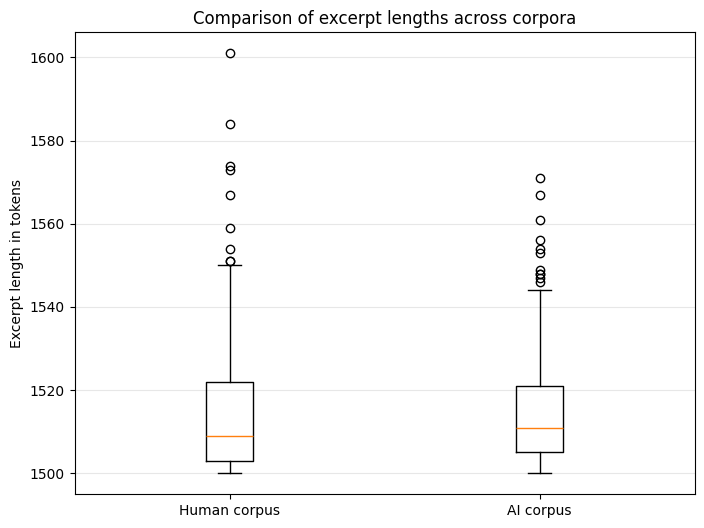

In [7]:
plt.figure(figsize=(8, 6))
plt.boxplot([human_lengths, ai_lengths], labels=["Human corpus", "AI corpus"])
plt.ylabel("Excerpt length in tokens")
plt.title("Comparison of excerpt lengths across corpora")
plt.grid(axis="y", alpha=0.3)
plt.show()

##### Marker indices computation

In [4]:
def Repeat_Rate(tokens):
    frequencies = Counter(tokens)
    n_tokens = len(tokens)
    RR = sum((frequency / n_tokens) ** 2 for frequency in frequencies.values())
    return RR

def H_entropy(tokens):
    frequencies = Counter(tokens)
    n_tokens = len(tokens)
    H = -sum(
    (raw_frequency / n_tokens) * math.log2(raw_frequency / n_tokens)
    for raw_frequency in frequencies.values()
    )
    return H

def R1_index(tokens):
    frequencies = sorted(Counter(tokens).values(), reverse=True)
    n_tokens = len(tokens)
    h=0
    for rank, frequency in enumerate(frequencies, start=1):
        if frequency >= rank:
            h=rank
        else: break

    cumulative_frequency = sum(frequencies[:h])
    f_h = cumulative_frequency / n_tokens
    approximation = (h**2) / (2*n_tokens)
    R1 = 1 - (f_h - approximation)
    return R1

def R_index(tokens):
    frequencies = sorted(Counter(tokens).values(), reverse=True)
    h=0
    for rank, frequency in enumerate(frequencies, start=1):
        if frequency >= rank:
            h=rank
        else: break
    V = len(frequencies)
    L_curve = 0.0
    for r in range(V - 1):
        D_r = math.sqrt((frequencies[r] - frequencies[r + 1]) ** 2 + 1)
        L_curve += D_r
    L_h = 0.0
    for r in range(h):
        D_r = math.sqrt((frequencies[r] - frequencies[r + 1]) ** 2 + 1)
        L_h += D_r

    R = 1 - (L_h / L_curve)
    return R

def Gini(tokens):
    frequencies = sorted(Counter(tokens).values(), reverse=True)  # descending
    V = len(frequencies)
    N = len(tokens)

    m_1 = sum(
        rank * frequency
        for rank, frequency in enumerate(frequencies, start=1)
    ) / N

    G = (1 / V) * (V + 1 - 2 * m_1)
    return G

def Hapax_Ratio(tokens):
    frequencies = Counter(tokens)
    V_h = sum(1 for frequency in frequencies.values() if frequency == 1)
    N = len(tokens)

    HR = V_h / N
    return HR

In [13]:
def collect_marker_values(excerpts):
    data = {
        "RR": {"human": [], "ai": []},
        "Entropy": {"human": [], "ai": []},
        "R1": {"human": [], "ai": []},
        "R": {"human": [], "ai": []},
        "Gini": {"human": [], "ai": []},
        "Hapax": {"human": [], "ai": []},
    }

    for excerpt in excerpts:
        tokens = excerpt["token_list"]
        label = excerpt["label"]

        group = "human" if label == 0 else "ai"

        data["RR"][group].append(Repeat_Rate(tokens))
        data["Entropy"][group].append(H_entropy(tokens))
        data["R1"][group].append(R1_index(tokens))
        data["R"][group].append(R_index(tokens))
        data["Gini"][group].append(Gini(tokens))
        data["Hapax"][group].append(Hapax_Ratio(tokens))

    return data

def plot_histogram_float(human_vals, ai_vals, metric):
    plt.figure()

    all_vals = human_vals + ai_vals
    bins = np.histogram_bin_edges(all_vals, bins=30)

    plt.hist(human_vals, bins=bins, alpha=0.5, label="Human")
    plt.hist(ai_vals, bins=bins, alpha=0.5, label="GPT-5.4")

    plt.xlabel(f"{metric} values")
    plt.ylabel("Frequency")
    plt.title(f"{metric} Distribution")
    plt.legend()

    plt.show()

def run_ks_test(human_vals, ai_vals):
    stat, p = ks_2samp(human_vals, ai_vals)

    return {
        "ks_statistic": stat,
        "p_value": p
    }


Processing: RR


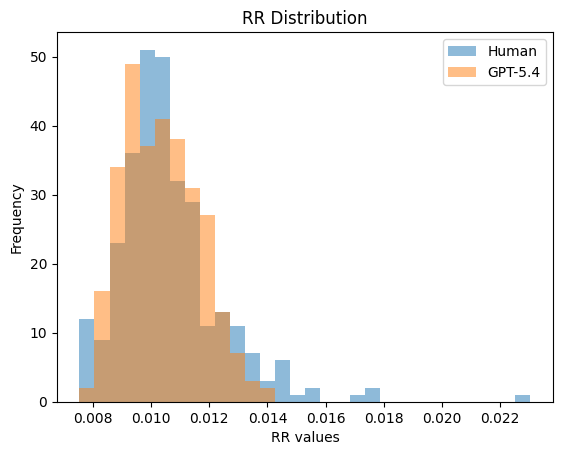


Processing: Entropy


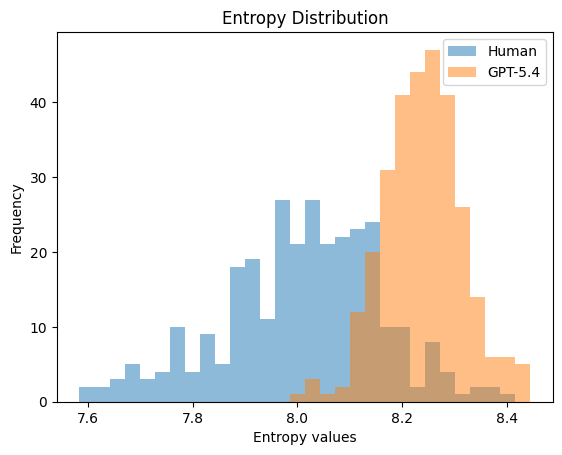


Processing: R1


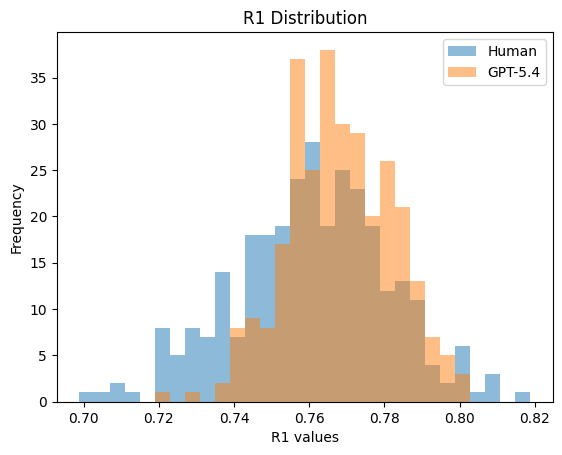


Processing: R


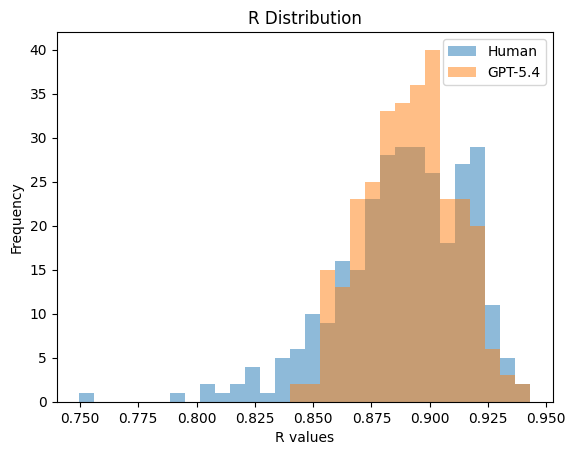


Processing: Gini


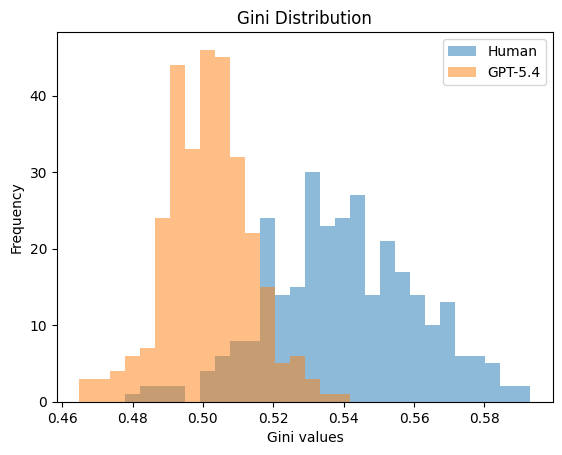


Processing: Hapax


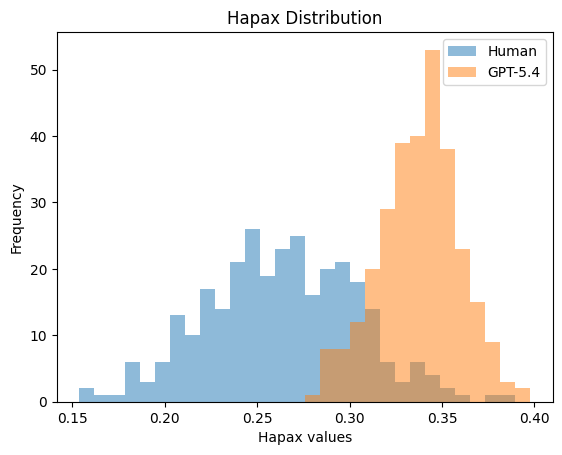


METRIC: RR
KS statistic: 0.09
KS p-value: 0.17609362474930004

METRIC: Entropy
KS statistic: 0.7433333333333333
KS p-value: 5.151584426655424e-81

METRIC: R1
KS statistic: 0.21333333333333335
KS p-value: 2.1664543157120107e-06

METRIC: R
KS statistic: 0.09666666666666666
KS p-value: 0.12122695053622792

METRIC: Gini
KS statistic: 0.7966666666666666
KS p-value: 3.6354757087208926e-95

METRIC: Hapax
KS statistic: 0.7866666666666666
KS p-value: 2.2646149017973313e-92


In [16]:
def run_marker_pipeline(excerpts):
    data = collect_marker_values(excerpts)
    results = {}

    for metric, values in data.items():
        print(f"\nProcessing: {metric}")

        human_vals = values["human"]
        ai_vals = values["ai"]

        plot_histogram_float(human_vals, ai_vals, metric)

        results[metric] = {
            "ks_test": run_ks_test(human_vals, ai_vals)
        }
    return results

marker_results = run_marker_pipeline(both_corpora_loaded)

for metric, res in marker_results.items():
    print("\n" + "=" * 40)
    print(f"METRIC: {metric}")
    print("=" * 40)

    print("KS statistic:", res["ks_test"]["ks_statistic"])
    print("KS p-value:", res["ks_test"]["p_value"])





In [8]:
marker_data = collect_marker_values(both_corpora_loaded)

summary_stats = {}

for metric, values in marker_data.items():
    summary_stats[metric] = {}
    
    for corpus in ["human", "ai"]:
        vals = values[corpus]
        summary_stats[metric][corpus] = {
            "mean": mean(vals),
            "median": median(vals),
            "stdev": stdev(vals)
        }

for metric, corpora in summary_stats.items():
    print("\n" + "=" * 40)
    print(f"METRIC: {metric}")
    print("=" * 40)
    
    for corpus, stats_dict in corpora.items():
        print(f"{corpus.capitalize()}:")
        print(f"  Mean:   {stats_dict['mean']}")
        print(f"  Median: {stats_dict['median']}")
        print(f"  Stdev:  {stats_dict['stdev']}")


METRIC: RR
Human:
  Mean:   0.010649308420128126
  Median: 0.010344683203094021
  Stdev:  0.0018262130473225239
Ai:
  Mean:   0.010346507075149482
  Median: 0.010269693666523382
  Stdev:  0.0012789338661853519

METRIC: Entropy
Human:
  Mean:   8.010610353930451
  Median: 8.022222146168497
  Stdev:  0.15237400097712764
Ai:
  Mean:   8.239477766756554
  Median: 8.239370087374994
  Stdev:  0.07538080362672284

METRIC: R1
Human:
  Mean:   0.7605650605397347
  Median: 0.761556262182007
  Stdev:  0.02058107570765678
Ai:
  Mean:   0.7680147502038137
  Median: 0.7676733250437757
  Stdev:  0.013975769048877963

METRIC: R
Human:
  Mean:   0.8880200821064084
  Median: 0.890894353237538
  Stdev:  0.0282568027145382
Ai:
  Mean:   0.8914317271216258
  Median: 0.892337540713199
  Stdev:  0.01976871422088941

METRIC: Gini
Human:
  Mean:   0.539952185602505
  Median: 0.5394024565910169
  Stdev:  0.02117947659901543
Ai:
  Mean:   0.5014504289036346
  Median: 0.5017248344223296
  Stdev:  0.0121416463177

##### Distributions computation

In [6]:
def extract_sentence_lengths(sentences):
    return [len(sentence.split()) for sentence in sentences]

def extract_parse_tree_depths(sentences, nlp):
    sentence_depths = []

    for sentence in sentences:
        doc = nlp(sentence)

        root = None
        for token in doc:
            if token.head == token:
                root = token
                break

        if root is None:
            continue  # safety

        max_depth = 0
        stack = [(root, 1)]

        while stack:
            node, depth = stack.pop()

            if depth > max_depth:
                max_depth = depth

            for child in node.children:
                stack.append((child, depth + 1))

        sentence_depths.append(max_depth)

    return sentence_depths

def collect_lengths(excerpts, labels, nlp):
    data = {
        "word": {"human": [], "ai": []},
        "sentence": {"human": [], "ai": []},
        "tree": {"human": [], "ai": []}
    }

    for excerpt, label in zip(excerpts, labels):
        tokens = excerpt["token_list"]
        sentences = excerpt["sentence_list"]

        word_lengths = [len(token) for token in tokens]
        sent_lengths = extract_sentence_lengths(sentences)
        tree_depths = extract_parse_tree_depths(sentences, nlp)

        group = "human" if label == 0 else "ai"

        data["word"][group].extend(word_lengths)
        data["sentence"][group].extend(sent_lengths)
        data["tree"][group].extend(tree_depths)

    return data


def build_aligned_frequencies(human_lengths, ai_lengths):
    human_counts = Counter(human_lengths)
    ai_counts = Counter(ai_lengths)

    observed_keys = set(human_counts.keys()) | set(ai_counts.keys())

    min_k = min(observed_keys)
    max_k = max(observed_keys)

    all_keys = list(range(min_k, max_k + 1))

    human_freq = [human_counts.get(k, 0) for k in all_keys]
    ai_freq = [ai_counts.get(k, 0) for k in all_keys]

    return all_keys, human_freq, ai_freq

def plot_distributions(keys, human_freq, ai_freq, metric):
    plt.figure()
    plt.plot(keys, human_freq, label="Human")
    plt.plot(keys, ai_freq, label="GPT-5.4")
    plt.xlabel(f"{metric} length")
    plt.ylabel("Frequency (counts)")
    plt.title(f"Empirical {metric} Distribution")
    plt.legend()
    plt.show()


def run_pipeline(excerpts, labels, nlp, output_path):
    results = {}

    data = collect_lengths(excerpts, labels, nlp)

    for metric in ["word", "sentence", "tree"]:
        print(f"Processing: {metric}")

        human_lengths = data[metric]["human"]
        ai_lengths = data[metric]["ai"]

        plot_histogram(human_lengths, ai_lengths, metric)

        keys, human_freq, ai_freq = build_aligned_frequencies(
            human_lengths, ai_lengths
        )

        plot_distributions(keys, human_freq, ai_freq, metric)

        ks_results = run_ks_test(human_lengths, ai_lengths)

        results[metric] = {
            "ks_test": ks_results
        }

    save_json(output_path, results)
    return results


def plot_histogram(human_lengths, ai_lengths, metric):
    import matplotlib.pyplot as plt

    plt.figure()

    all_data = human_lengths + ai_lengths
    bins = range(min(all_data), max(all_data) + 2)

    plt.hist(human_lengths, bins=bins, alpha=0.5, label="Human")
    plt.hist(ai_lengths, bins=bins, alpha=0.5, label="GPT-5.4")

    plt.xlabel(f"{metric} length")
    plt.ylabel("Frequency (counts)")
    plt.title(f"{metric.capitalize()} Length Histogram")
    plt.legend()

    plt.show()


Processing: word


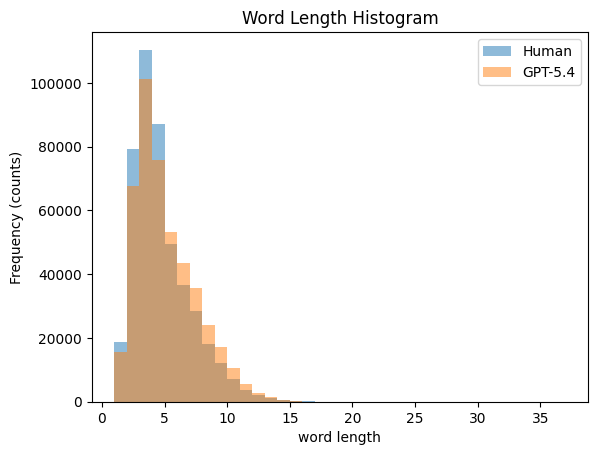

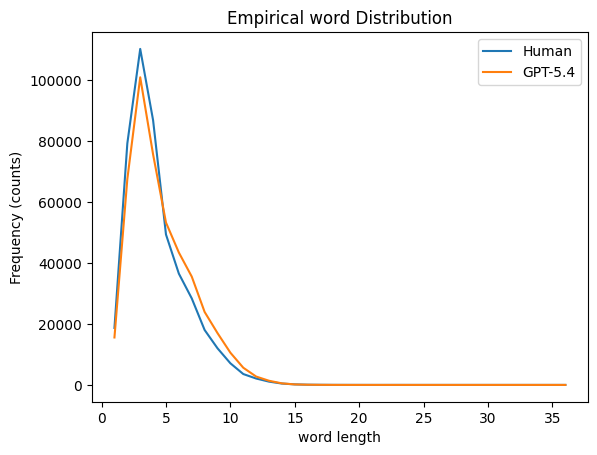

Processing: sentence


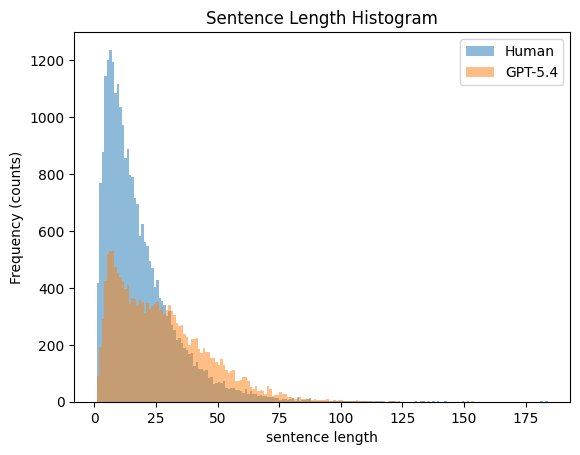

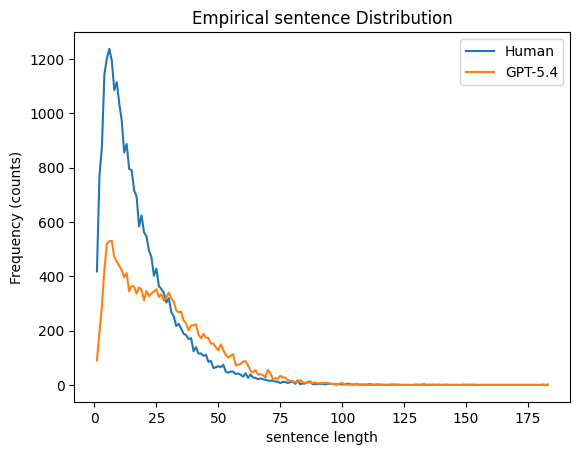

Processing: tree


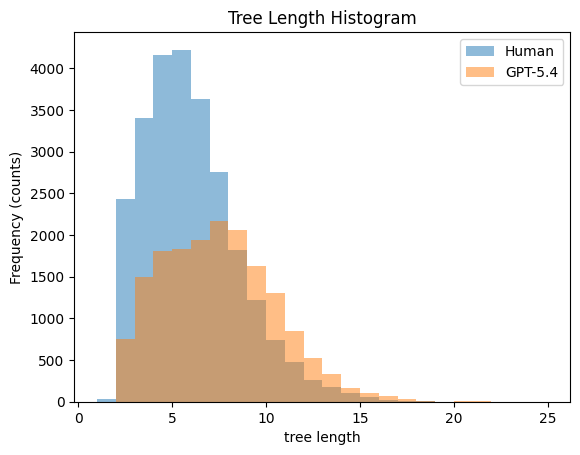

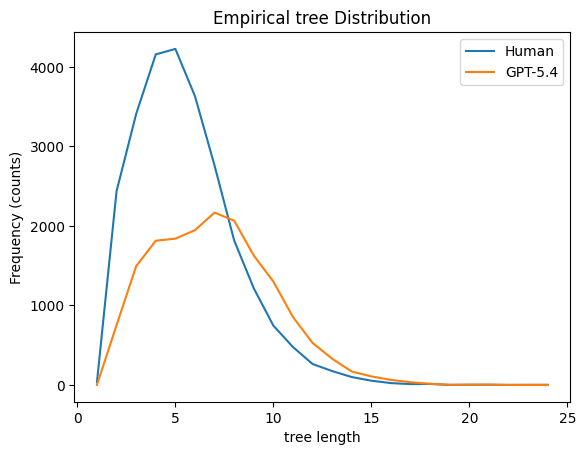


METRIC: word
K-S statistic: 0.07786559604818566
K-S p-value: 0.0

METRIC: sentence
K-S statistic: 0.24487031826182054
K-S p-value: 0.0

METRIC: tree
K-S statistic: 0.2419914553047347
K-S p-value: 0.0
Results saved to: distribution_analysis.json


In [17]:
OUTPUT_PATH = Path("distribution_analysis.json")

results = run_pipeline(both_corpora_loaded, labels, nlp, OUTPUT_PATH)

for metric, res in results.items():
    print("\n" + "=" * 40)
    print(f"METRIC: {metric}")

    print("K-S statistic:", res["ks_test"]["ks_statistic"])
    print("K-S p-value:", res["ks_test"]["p_value"])

print("Results saved to:", OUTPUT_PATH)

In [18]:
length_data = collect_lengths(both_corpora_loaded, labels, nlp)

summary_stats = {}

for metric, values in length_data.items():
    summary_stats[metric] = {}
    
    for corpus in ["human", "ai"]:
        vals = values[corpus]
        summary_stats[metric][corpus] = {
            "mean": mean(vals),
            "median": median(vals),
            "stdev": stdev(vals)
        }

for metric, corpora in summary_stats.items():
    print("\n" + "=" * 40)
    print(f"METRIC: {metric}")
    print("=" * 40)
    
    for corpus, stats_dict in corpora.items():
        print(f"{corpus.capitalize()}:")
        print(f"  Mean:   {stats_dict['mean']}")
        print(f"  Median: {stats_dict['median']}")
        print(f"  Stdev:  {stats_dict['stdev']}")

KeyboardInterrupt: 

##### Zipf, Heaps computation

In [19]:
def Zipf(tokens):
    token_frequencies = Counter(tokens)

    frequencies = np.array(
        sorted(token_frequencies.values(), reverse=True),
        dtype=float
    )

    ranks = np.arange(1, len(frequencies) + 1, dtype=float)

    x = np.log(ranks)
    log_y = np.log(frequencies)
    slope, intercept = np.polyfit(x, log_y, 1)

    predicted_log_y = slope * x + intercept
    residuals = log_y - predicted_log_y

    residual_sum_of_squares = np.sum(residuals ** 2)
    total_sum_of_squares = np.sum((log_y - np.mean(log_y)) ** 2)

    r_squared = 1 - (residual_sum_of_squares / total_sum_of_squares)
    rmse = math.sqrt(np.mean(residuals ** 2))

    beta = -slope

    return {
        "beta": float(beta),
        "slope": float(slope),        
        "intercept": float(intercept),
        "r_squared": float(r_squared),
        "rmse": float(rmse)
    }

def Heaps(tokens):
    positions = []
    vocabulary_sizes = []

    seen_types = set()

    for position, token in enumerate(tokens, start=1):
        seen_types.add(token)
        positions.append(position)
        vocabulary_sizes.append(len(seen_types))

    log_x = np.log(positions)
    log_y = np.log(vocabulary_sizes)

    line_coefficients = np.polyfit(log_x, log_y, 1)
    slope = line_coefficients[0]
    intercept = line_coefficients[1]

    predicted_values = slope * log_x + intercept

    residuals = log_y - predicted_values
    residual_sum_of_squares = np.sum(residuals ** 2)

    deviations_from_mean = log_y - np.mean(log_y)
    total_sum_of_squares = np.sum(deviations_from_mean ** 2)


    r_squared = 1 - (residual_sum_of_squares / total_sum_of_squares)
    rmse = math.sqrt(np.mean(residuals ** 2))


    return {
        "slope": float(slope),
        "r_squared": float(r_squared),
        "rmse": float(rmse)
    }



In [20]:
def collect_zipf_heaps(excerpts):
    data = {
        "Zipf_slope": {"human": [], "ai": []},
        "Zipf_R^2": {"human": [], "ai": []},
        "Zipf_RMSE": {"human": [], "ai": []},
        "Heaps_exponent": {"human": [], "ai": []},
        "Heaps_R^2": {"human": [], "ai": []},
        "Heaps_RMSE": {"human": [], "ai": []},
    }

    for excerpt in excerpts:
        tokens = excerpt["token_list"]
        label = excerpt["label"]

        group = "human" if label == 0 else "ai"

        zipf_res = Zipf(tokens)
        heaps_res = Heaps(tokens)

        data["Zipf_slope"][group].append(zipf_res["slope"])
        data["Zipf_R^2"][group].append(zipf_res["r_squared"])
        data["Zipf_RMSE"][group].append(zipf_res["rmse"])

        data["Heaps_exponent"][group].append(heaps_res["slope"])
        data["Heaps_R^2"][group].append(heaps_res["r_squared"])
        data["Heaps_RMSE"][group].append(heaps_res["rmse"])

    return data

def run_zipf_heaps_pipeline(excerpts):
    data = collect_zipf_heaps(excerpts)
    results = {}

    for metric, values in data.items():
        print(f"\nProcessing: {metric}")

        human_vals = values["human"]
        ai_vals = values["ai"]

        plot_histogram_float(human_vals, ai_vals, metric)

        results[metric] = {
            "ks_test": run_ks_test(human_vals, ai_vals)
        }

    return results


Processing: Zipf_slope


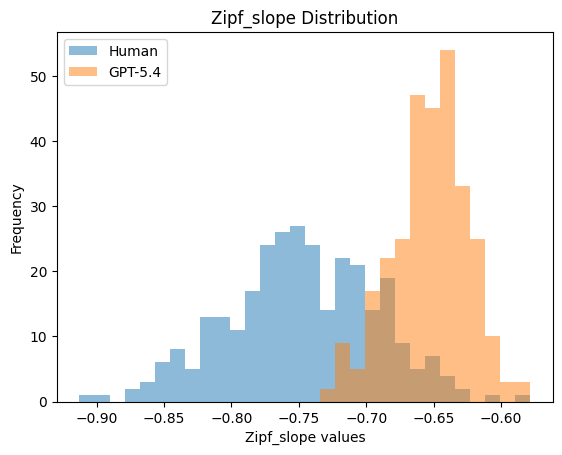


Processing: Zipf_R^2


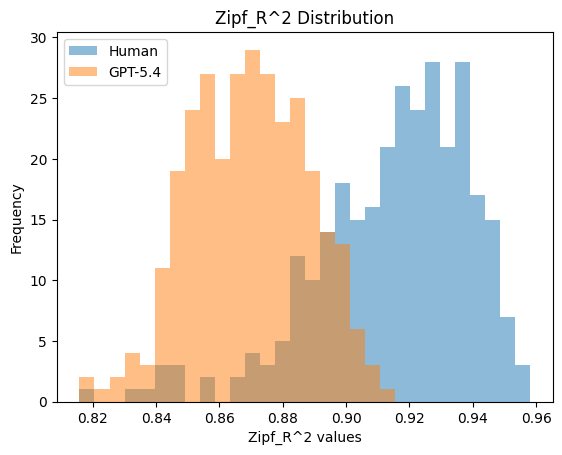


Processing: Zipf_RMSE


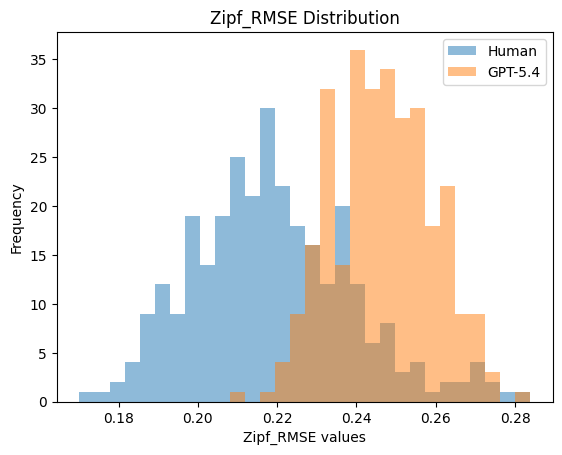


Processing: Heaps_exponent


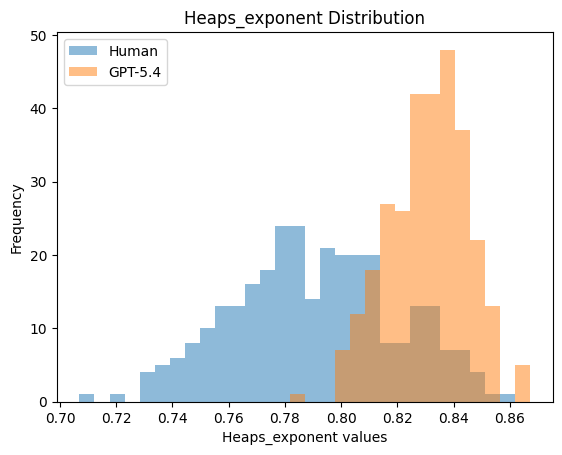


Processing: Heaps_R^2


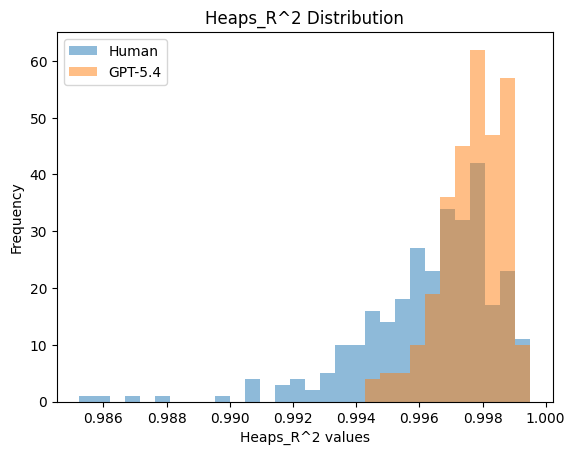


Processing: Heaps_RMSE


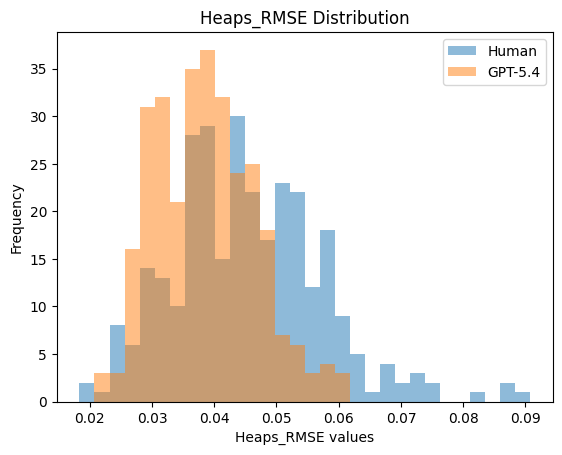


METRIC: Zipf_slope
KS statistic: 0.7466666666666667
KS p-value: 7.570076352146329e-82

METRIC: Zipf_R^2
KS statistic: 0.73
KS p-value: 9.542394796184281e-78

METRIC: Zipf_RMSE
KS statistic: 0.65
KS p-value: 4.3489102261263e-60

METRIC: Heaps_exponent
KS statistic: 0.6766666666666666
KS p-value: 1.2617570371375253e-65

METRIC: Heaps_R^2
KS statistic: 0.3466666666666667
KS p-value: 2.1942743021891237e-16

METRIC: Heaps_RMSE
KS statistic: 0.2966666666666667
KS p-value: 4.783786471507949e-12
Zipf/Heaps analysis saved to: distribution_analysis.json


In [21]:
zipf_heaps_results = run_zipf_heaps_pipeline(excerpts=both_corpora_loaded)

for metric, res in zipf_heaps_results.items():
    print("\n" + "=" * 40)
    print(f"METRIC: {metric}")
    print("=" * 40)

    print("KS statistic:", res["ks_test"]["ks_statistic"])
    print("KS p-value:", res["ks_test"]["p_value"])

save_json(OUTPUT_PATH, zipf_heaps_results)
print("Zipf/Heaps analysis saved to:", OUTPUT_PATH)

In [ ]:
zipf_heaps_data = collect_zipf_heaps(both_corpora_loaded)

summary_stats = {}

for metric, values in zipf_heaps_data.items():
    summary_stats[metric] = {}
    
    for corpus in ["human", "ai"]:
        vals = values[corpus]
        summary_stats[metric][corpus] = {
            "mean": mean(vals),
            "median": median(vals),
            "stdev": stdev(vals)
        }

for metric, corpora in summary_stats.items():
    print("\n" + "=" * 40)
    print(f"METRIC: {metric}")
    print("=" * 40)
    
    for corpus, stats_dict in corpora.items():
        print(f"{corpus.capitalize()}:")
        print(f"  Mean:   {stats_dict['mean']}")
        print(f"  Median: {stats_dict['median']}")
        print(f"  Stdev:  {stats_dict['stdev']}")


METRIC: Zipf_slope
Human:
  Mean:   -0.7476554143162194
  Median: -0.7487566498121612
  Stdev:  0.05524277469537486
Ai:
  Mean:   -0.6528205800207909
  Median: -0.6514560546200016
  Stdev:  0.02808943717624856

METRIC: Zipf_R^2
Human:
  Mean:   0.9149334664594962
  Median: 0.9188106016606903
  Stdev:  0.024420945963869425
Ai:
  Mean:   0.8694899938180266
  Median: 0.8698439301961358
  Stdev:  0.018398491899777682

METRIC: Zipf_rmse
Human:
  Mean:   0.21900663420250785
  Median: 0.21693330518728265
  Stdev:  0.02028052568933966
Ai:
  Mean:   0.24674004117047055
  Median: 0.24672686064876895
  Stdev:  0.012509224419330226

METRIC: Heaps_beta
Human:
  Mean:   0.7904963819006455
  Median: 0.790203747069334
  Stdev:  0.028861423672285735
Ai:
  Mean:   0.8309640677581042
  Median: 0.8313393918229366
  Stdev:  0.0139759101842338

METRIC: Heaps_R^2
Human:
  Mean:   0.9963129002838089
  Median: 0.9967958885586794
  Stdev:  0.002197030046343369
Ai:
  Mean:   0.9976923021623914
  Median: 0.99782

##### Menzerath

In [4]:
def normalise_token_for_syllables(word):
    word = str(word).lower()

    word = re.sub(
        r"[^a-zàáâäæãåāèéêëēėęìíîïīòóôöõøōùúûüūýÿ' -]",
        "",
        word)

    word = (
        word.replace("à", "a").replace("á", "a").replace("â", "a").replace("ä", "a")
            .replace("æ", "ae").replace("ã", "a").replace("å", "a").replace("ā", "a")
            .replace("è", "e").replace("é", "e").replace("ê", "e").replace("ë", "e")
            .replace("ē", "e").replace("ė", "e").replace("ę", "e")
            .replace("ì", "i").replace("í", "i").replace("î", "i").replace("ï", "i").replace("ī", "i")
            .replace("ò", "o").replace("ó", "o").replace("ô", "o").replace("ö", "o")
            .replace("õ", "o").replace("ø", "o").replace("ō", "o")
            .replace("ù", "u").replace("ú", "u").replace("û", "u").replace("ü", "u").replace("ū", "u")
            .replace("ý", "y").replace("ÿ", "y")
    )

    word = word.replace("'", "").replace(" ", "").replace("-", "")
    return word


def is_vowel(phoneme):
    return phoneme[-1].isdigit()


def count_syllables(word):
    normalized = normalise_token_for_syllables(word)

    if not normalized:
        return 0

    if normalized in cmu_dict:
        counts = [sum(1 for p in pron if is_vowel(p)) for pron in cmu_dict[normalized]]
        if counts:
            return int(round(float(np.median(counts))))

    count = len(re.findall(r"[aeiouy]+", normalized)) or 1

    if normalized.endswith("e") and not normalized.endswith(("le", "ye")) and count > 1:
        count -= 1
    if normalized.endswith("ed") and len(normalized) > 3:
        if not re.search(r"[td]ed$", normalized) and count > 1:
            count -= 1
    if normalized.endswith("es") and len(normalized) > 3:
        if not re.search(r"(ses|xes|zes|ches|shes)$", normalized) and count > 1:
            count -= 1
    if re.search(r"[^aeiouy]le$", normalized):
        count += 1

    return max(1, count)


def count_phonemes(word):
    normalized = normalise_token_for_syllables(word)

    if normalized in cmu_dict:
        counts = [len(pron) for pron in cmu_dict[normalized]]
        if counts:
            return int(round(float(np.median(counts))))

    patterns = sorted([
        "augh", "igh", "tch", "dge", "ch", "sh", "th", "ph", "gh", "ng", "ck",
        "qu", "wh", "ee", "oo", "ou", "ow", "oi", "oy", "ai", "ay",
        "ea", "oa", "ie"
    ], key=len, reverse=True)

    w = normalized.lower()
    count = 0
    i = 0

    while i < len(w):
        match = next((p for p in patterns if w.startswith(p, i)), None)
        if match:
            count += 1
            i += len(match)
        else:
            count += int(w[i].isalpha())
            i += 1

    if w.endswith("e") and not w.endswith(("le", "ye")) and count > 1:
        count -= 1

    return max(1, count)


In [5]:
def get_word_level_observations(excerpt):

    words = sorted({
        normalized
        for token in excerpt["token_list"]
        for normalized in [normalise_token_for_syllables(token)]
        if normalized})
    
    observations = []

    for word in words:
        syllables = count_syllables(word)
        phonemes = count_phonemes(word)

        if syllables <= 0:
            continue

        x = float(syllables) # number of syllables in word
        y_raw = float(phonemes) / float(syllables) # average phonemes per syllable
        observations.append((x, y_raw))

    return observations

def get_sentence_level_observations(excerpt):
    observations = []

    for sentence in excerpt["sentence_list"]:
        tokens = sentence.split()
        tokens = [normalise_token_for_syllables(token) for token in tokens]
        tokens = [token for token in tokens if token]
        if not tokens:
            continue

        n_words = len(tokens)
        syllable_counts = [count_syllables(token) for token in tokens]

        x = float(n_words) # number of words in sentence
        y_raw = float(np.mean(syllable_counts)) # mean syllables per word

        observations.append((x, y_raw))

    return observations


def build_grouped_mal_table(observations):
    grouped = {}

    for x, y_raw in observations:
        x = int(x)
        grouped.setdefault(x, []).append(float(y_raw))

    x_values = range(min(grouped.keys()), max(grouped.keys()) + 1)

    rows = []
    for x in x_values:
        y_values = grouped.get(x, [])

        rows.append({
            "x": float(x),
            "n_x": int(len(y_values)),
            "y_observed": float(np.mean(y_values)) if y_values else float("nan")})
    return rows

def mal_function(x, a, b):
    return a * np.power(x, -b)

def fit_mal_for_text_from_observations(observations, label, alpha=0.05):
    grouped_rows = build_grouped_mal_table(observations)

    corpus = "human" if label == 0 else "ai"

    result = {
        "corpus": corpus,
        "b": float("nan"),
        "r_squared": float("nan"),
        "rmse": float("nan"),
        "spearman_ρ": float("nan"),
        "spearman_p_value": float("nan"),
        "n_observations": int(len(observations)),
        "n_groups": int(len(grouped_rows))
    }

    grouped_rows = [row for row in grouped_rows if not math.isnan(row["y_observed"])]
    x = np.array([row["x"] for row in grouped_rows], dtype=float)
    y = np.array([row["y_observed"] for row in grouped_rows], dtype=float)


    rho, p_value = spearmanr(x, y)
    result["spearman_ρ"] = float(rho)
    result["spearman_p_value"] = float(p_value)

    if np.any(x <= 0) or np.any(y <= 0):
        return result

    log_x = np.log(x)
    log_y = np.log(y)

    slope, intercept = np.polyfit(log_x, log_y, 1)

    b = -slope
    a = np.exp(intercept)

    predicted_log_y = slope * log_x + intercept
    residuals = log_y - predicted_log_y

    residual_sum_of_squares = np.sum(residuals ** 2)
    total_sum_of_squares = np.sum((log_y - np.mean(log_y)) ** 2)

    r_squared = 1 - (residual_sum_of_squares / total_sum_of_squares) if total_sum_of_squares > 0 else float("nan")
    rmse = math.sqrt(np.mean(residuals ** 2))

    result.update({
        "b": float(b),
        "r_squared": float(r_squared),
        "rmse": float(rmse)
    })

    return result

def collect_mal_word_results(excerpts):
    results = []

    for i, excerpt in enumerate(excerpts):
        observations = get_word_level_observations(excerpt)

        row = fit_mal_for_text_from_observations(
            observations=observations,
            label=excerpt["label"])
        row["level"] = "word"
        results.append(row)

    return results

def collect_mal_sentence_results(excerpts):
    results = []

    for i, excerpt in enumerate(excerpts):
        observations = get_sentence_level_observations(excerpt)

        row = fit_mal_for_text_from_observations(
            observations=observations,
            label=excerpt["label"])
        row["level"] = "sentence"
        results.append(row)

    return results


def plot_metric_histogram(results, metric, title, bins=20):
    human_values = np.array(
        [row[metric] for row in results
         if row["corpus"] == "human" and not math.isnan(row[metric])],
        dtype=float
    )

    ai_values = np.array(
        [row[metric] for row in results
         if row["corpus"] == "ai" and not math.isnan(row[metric])],
        dtype=float
    )

    plt.figure(figsize=(10, 6))
    plt.hist(human_values, bins=bins, alpha=0.5, label="Human")
    plt.hist(ai_values, bins=bins, alpha=0.5, label="AI")
    plt.xlabel(metric)
    plt.ylabel("Frequency")
    plt.title(title)
    plt.legend()
    plt.show()

    ks_result = None
    if len(human_values) > 0 and len(ai_values) > 0:
        ks_result = ks_2samp(human_values, ai_values)
        print(f"{title}")
        print(f"K-S statistic: {ks_result.statistic:.4f}")
        print(f"K-S p-value: {ks_result.pvalue:.6g}")

    return {
        "human_values": human_values,
        "ai_values": ai_values,
        "ks_result": ks_result
    }


def plot_all_mal_distributions(results, level_name="MAL"):
    metrics = [
        ("b", f"{level_name}: Distribution of exponent"),
        ("spearman_ρ", f"{level_name}: Distribution of Spearman ρ"),
        ("r_squared", f"{level_name}: Distribution of R²"),
        ("rmse", f"{level_name}: Distribution of RMSE"),
    ]

    outputs = {}
    for metric, title in metrics:
        outputs[metric] = plot_metric_histogram(results, metric, title)

    return outputs


def print_mal_summary(results, alpha=0.05):
    for corpus in ["human", "ai"]:
        subset = [row for row in results if row["corpus"] == corpus]

        print(f"\nCORPUS: {corpus.upper()}")
        print("Texts total:", len(subset))

        for metric in ["b", "spearman_ρ", "spearman_p_value", "r_squared", "rmse"]:
            values = np.array(
                [row[metric] for row in subset],
                dtype=float
            )
            if len(values) > 0:
                print(
                    f"{metric}: mean={np.mean(values):.4f}, "
                    f"median={np.median(values):.4f}, "
                    f"sd={np.std(values):.4f}"
                )
            else:
                print(f"{metric}: no valid values")

    pvals = np.array(
            [row["spearman_p_value"] for row in subset],
            dtype=float)

    significant_pvals = pvals[pvals < alpha]

    print(f"texts with p < {alpha}: {len(significant_pvals)}")
    print(f"texts with p >= {alpha}: {len(pvals) - len(significant_pvals)}")





WORD-LEVEL MAL RESULTS

CORPUS: HUMAN
Texts total: 300
b: mean=0.2237, median=0.2217, sd=0.0435
spearman_ρ: mean=-0.9167, median=-1.0000, sd=0.1444
spearman_p_value: mean=0.0425, median=0.0000, sd=0.1058
r_squared: mean=0.9002, median=0.9426, sd=0.1328
rmse: mean=0.0377, median=0.0324, sd=0.0207

CORPUS: AI
Texts total: 300
b: mean=0.2471, median=0.2491, sd=0.0290
spearman_ρ: mean=-0.9587, median=-1.0000, sd=0.0771
spearman_p_value: mean=0.0115, median=0.0000, sd=0.0386
r_squared: mean=0.9486, median=0.9667, sd=0.0605
rmse: mean=0.0302, median=0.0279, sd=0.0148
texts with p < 0.05: 292
texts with p >= 0.05: 8


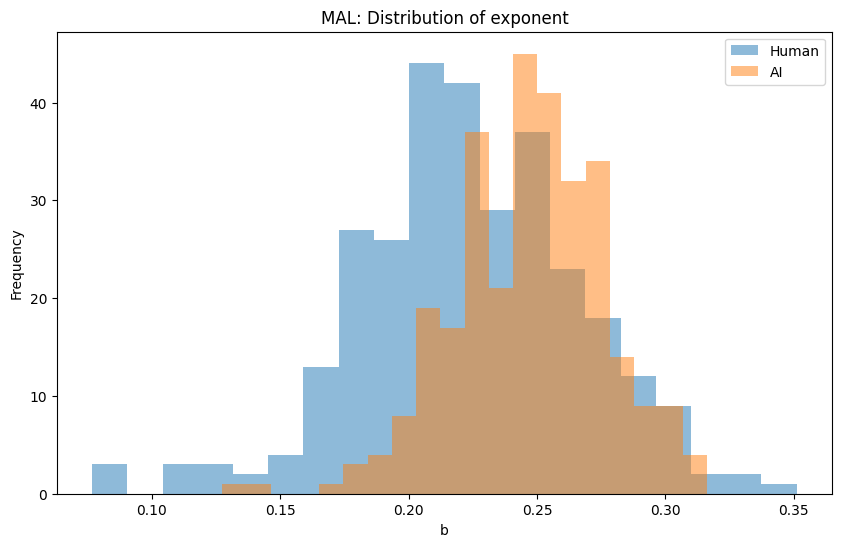

MAL: Distribution of exponent
K-S statistic: 0.3267
K-S p-value: 1.45821e-14


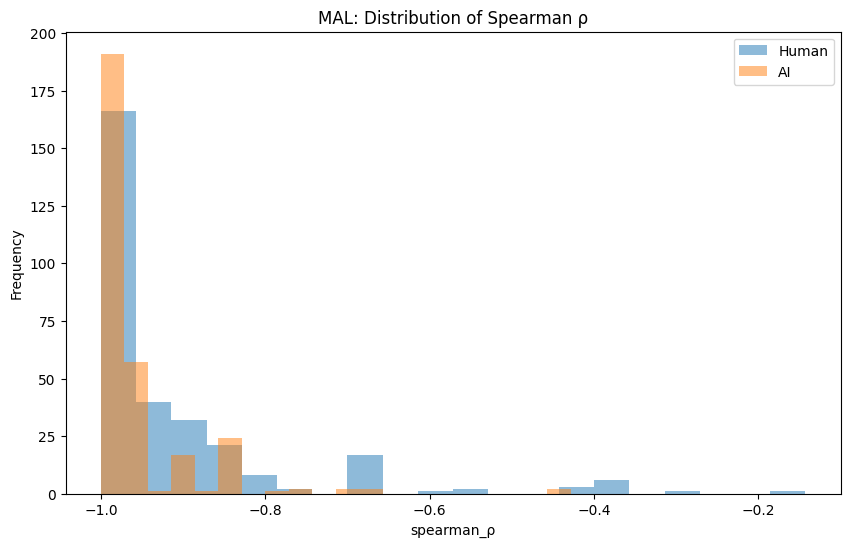

MAL: Distribution of Spearman ρ
K-S statistic: 0.1433
K-S p-value: 0.00416476


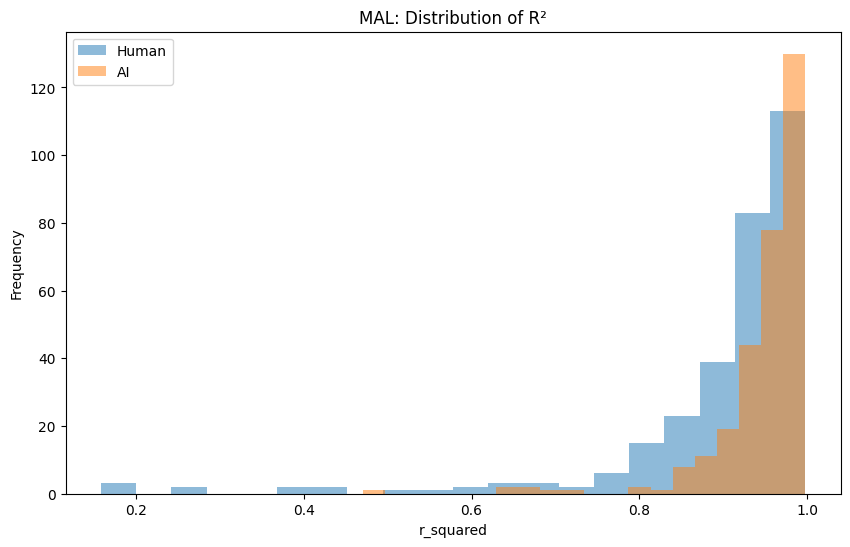

MAL: Distribution of R²
K-S statistic: 0.2667
K-S p-value: 8.69012e-10


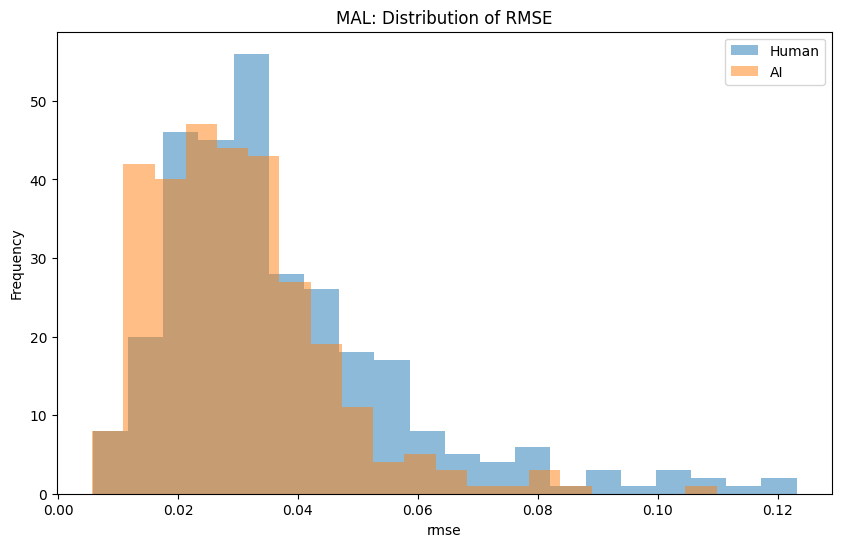

MAL: Distribution of RMSE
K-S statistic: 0.1633
K-S p-value: 0.000653837
SENTENCE-LEVEL MAL RESULTS

CORPUS: HUMAN
Texts total: 300
b: mean=-0.0073, median=-0.0093, sd=0.0401
spearman_ρ: mean=0.1206, median=0.1202, sd=0.2090
spearman_p_value: mean=0.3867, median=0.3350, sd=0.3020
r_squared: mean=0.1011, median=0.0507, sd=0.1182
rmse: mean=0.1049, median=0.1014, sd=0.0247

CORPUS: AI
Texts total: 300
b: mean=-0.0207, median=-0.0263, sd=0.0419
spearman_ρ: mean=0.1264, median=0.1563, sd=0.2407
spearman_p_value: mean=0.3143, median=0.2077, sd=0.2970
r_squared: mean=0.1083, median=0.0774, sd=0.1073
rmse: mean=0.1032, median=0.1008, sd=0.0188
texts with p < 0.05: 71
texts with p >= 0.05: 229


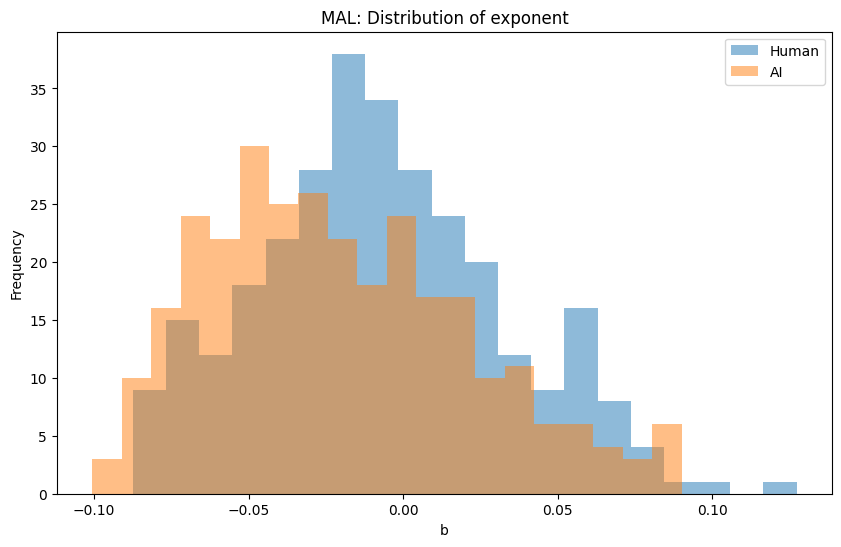

MAL: Distribution of exponent
K-S statistic: 0.1933
K-S p-value: 2.56214e-05


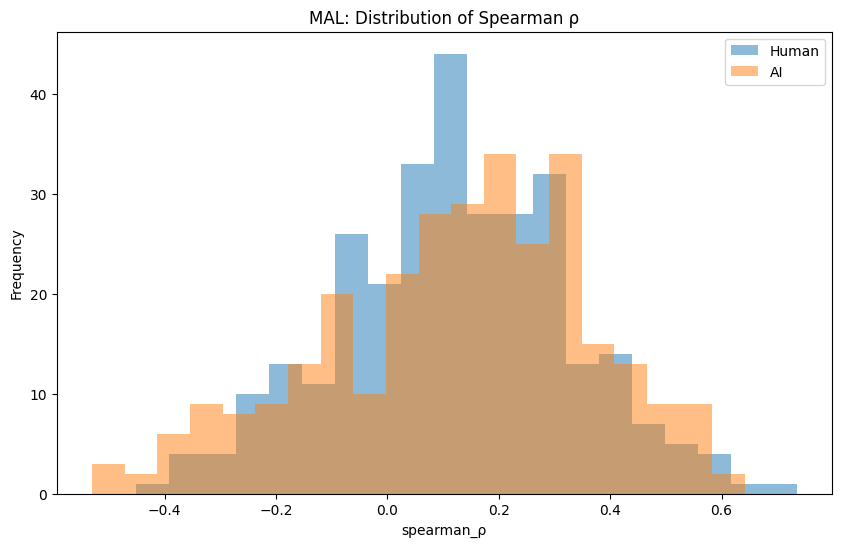

MAL: Distribution of Spearman ρ
K-S statistic: 0.0867
K-S p-value: 0.210057


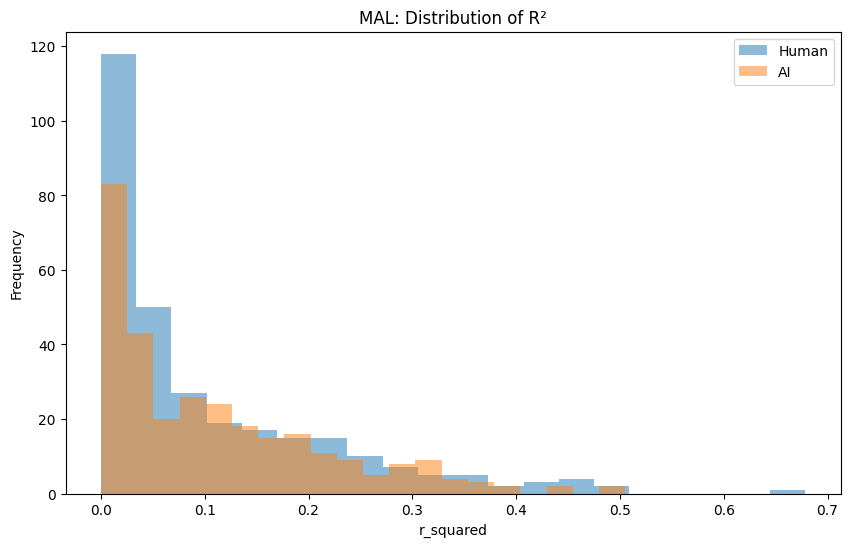

MAL: Distribution of R²
K-S statistic: 0.1033
K-S p-value: 0.0812185


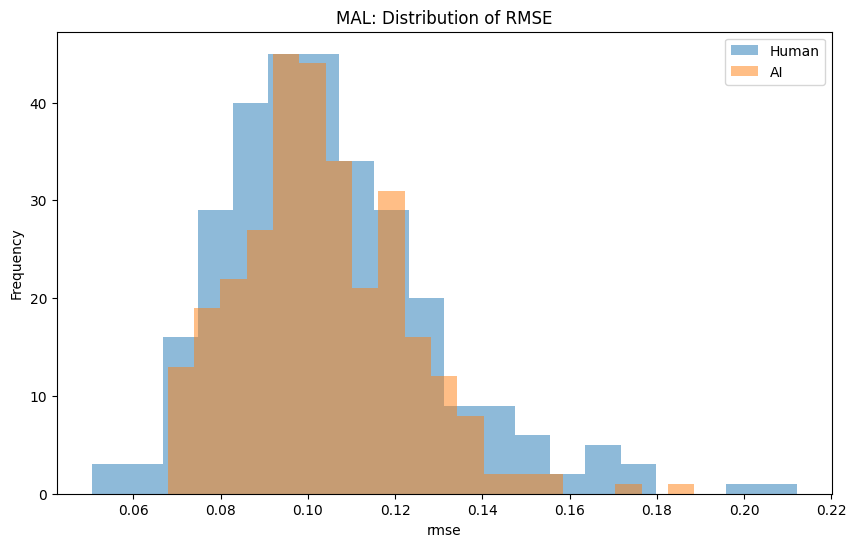

MAL: Distribution of RMSE
K-S statistic: 0.0667
K-S p-value: 0.518269


{'b': {'human_values': array([ 5.66155306e-02, -4.58671338e-02,  3.97243783e-02,  1.63881255e-02,
         -6.47064129e-02,  7.33856409e-02, -2.04085599e-02, -8.15342246e-02,
         -2.18834233e-02, -3.22981173e-02,  4.30022759e-02, -4.17139663e-02,
          3.23292956e-02, -6.08494213e-02,  3.67571041e-02,  1.64358221e-02,
          4.78947747e-02, -5.39136375e-02, -2.16404132e-02, -3.05780464e-02,
         -1.61340680e-02,  2.68015273e-02,  7.59961841e-02, -3.04608040e-02,
         -6.05200750e-02, -6.94353039e-02, -2.23813258e-02, -7.06105601e-02,
          1.92205352e-02,  8.99447225e-04, -1.51419253e-02,  1.27268203e-01,
         -2.33164665e-02,  1.07126918e-02, -4.54064876e-02, -4.45023845e-02,
         -1.52043147e-02,  6.04762019e-02, -3.80347962e-02,  2.89225997e-02,
          8.27331699e-02, -4.01741179e-02, -3.67352124e-02, -4.38288730e-02,
          9.28379429e-02, -4.13682678e-02, -4.88281944e-03,  6.63772973e-02,
         -1.41283193e-02, -1.32066331e-02, -3.16476524e

In [6]:
mal_word_results = collect_mal_word_results(both_corpora_loaded)
mal_sentence_results = collect_mal_sentence_results(both_corpora_loaded)

print("WORD-LEVEL MAL RESULTS")
print_mal_summary(mal_word_results)
plot_all_mal_distributions(mal_word_results)


print("SENTENCE-LEVEL MAL RESULTS")
print_mal_summary(mal_sentence_results)
plot_all_mal_distributions(mal_sentence_results)


Human table:
    sentence_length_words  n_sentences  mean_word_length_syllables  \
0                       1          409                    1.518337   
1                       2          756                    1.393519   
2                       3          868                    1.345622   
3                       4         1128                    1.333777   
4                       5         1201                    1.328060   
5                       6         1213                    1.321929   
6                       7         1183                    1.324115   
7                       8         1092                    1.328297   
8                       9         1091                    1.326102   
9                      10         1042                    1.345969   
10                     11          967                    1.338347   
11                     12          865                    1.343931   
12                     13          881                    1.331005   
13     

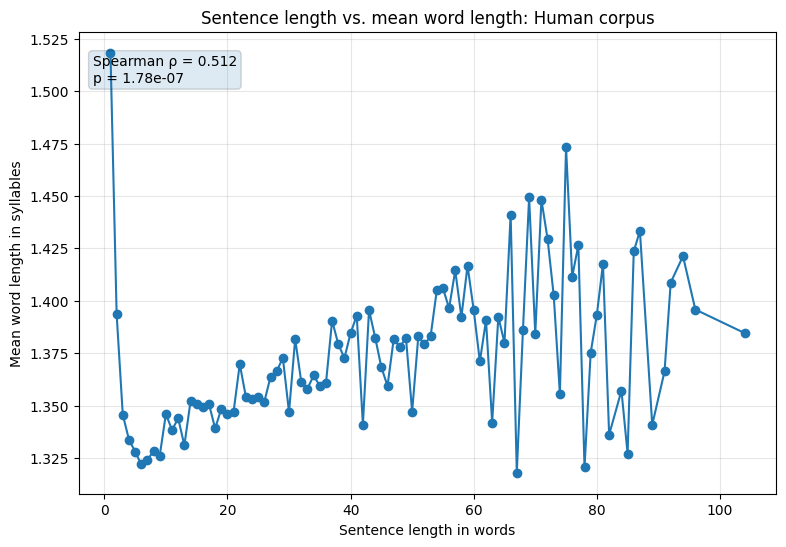

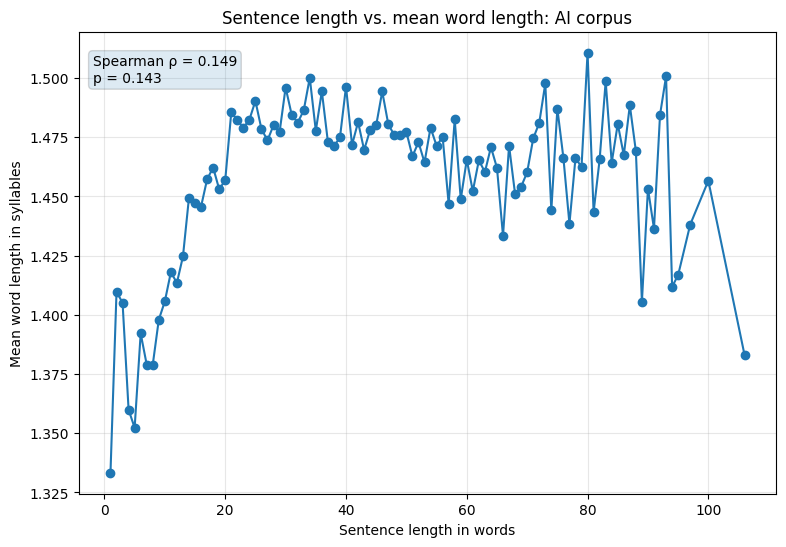


Human result:
{'spearman_rho': 0.5123992417120047, 'spearman_p_value': 1.7762319215950227e-07}

AI result:
{'spearman_rho': 0.1489139235825539, 'spearman_p_value': 0.1433494373032433}


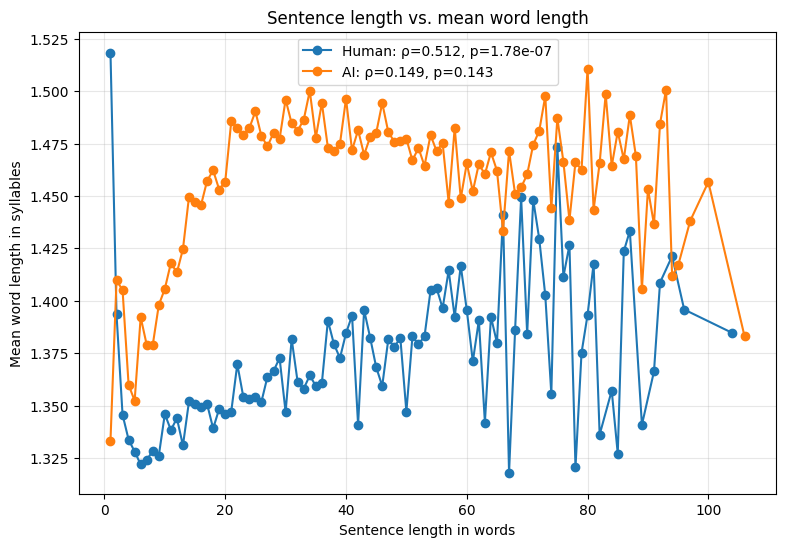


Comparison result:
{'human_spearman_rho': 0.5123992417120047, 'human_spearman_p_value': 1.7762319215950227e-07, 'ai_spearman_rho': 0.1489139235825539, 'ai_spearman_p_value': 0.1433494373032433}


In [8]:
# ============================================================
# Diagnostic plot: Sentence length vs. mean word length
# ============================================================

from collections import defaultdict
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr


def build_sentence_length_vs_mean_word_length_table(
    excerpts,
    label=None,
    min_sentences_per_length=5
):
    """
    Builds a table for the requested MAL diagnostic plot.

    x-axis:
        sentence length in words

    y-axis:
        mean word length in syllables
        for all sentences of that sentence length

    Parameters:
        excerpts: list of excerpt dictionaries
        label:
            None = use all texts
            0 = use only human texts
            1 = use only AI texts
        min_sentences_per_length:
            minimum number of sentences required for a sentence length
            to be included in the final plot
    """

    grouped = defaultdict(list)

    for excerpt in excerpts:
        if label is not None and int(excerpt["label"]) != int(label):
            continue

        for sentence in excerpt["sentence_list"]:
            tokens = tokenize(sentence)

            normalized_tokens = [
                normalise_token_for_syllables(token)
                for token in tokens
            ]

            normalized_tokens = [
                token for token in normalized_tokens
                if token
            ]

            if not normalized_tokens:
                continue

            syllable_counts = [
                count_syllables(token)
                for token in normalized_tokens
            ]

            syllable_counts = [
                count for count in syllable_counts
                if count > 0
            ]

            if not syllable_counts:
                continue

            sentence_length_words = len(normalized_tokens)
            mean_word_length_syllables = float(np.mean(syllable_counts))

            grouped[sentence_length_words].append(
                mean_word_length_syllables
            )

    rows = []

    for sentence_length_words in sorted(grouped.keys()):
        values = grouped[sentence_length_words]

        rows.append({
            "sentence_length_words": sentence_length_words,
            "n_sentences": len(values),
            "mean_word_length_syllables": float(np.mean(values)),
            "sd_word_length_syllables": float(np.std(values)),
        })

    table = pd.DataFrame(rows)

    table = table[
        table["n_sentences"] >= min_sentences_per_length
    ].reset_index(drop=True)

    return table


def plot_sentence_length_vs_mean_word_length(
    table,
    title,
    output_path=None
):
    """
    Plots:
        x = sentence length in words
        y = mean word length in syllables
    """

    x = table["sentence_length_words"].values
    y = table["mean_word_length_syllables"].values

    rho, p_value = spearmanr(x, y)

    plt.figure(figsize=(9, 6))
    plt.plot(x, y, marker="o", linewidth=1.5)

    plt.xlabel("Sentence length in words")
    plt.ylabel("Mean word length in syllables")
    plt.title(title)
    plt.grid(alpha=0.3)

    plt.text(
        0.02,
        0.95,
        f"Spearman ρ = {rho:.3f}\np = {p_value:.3g}",
        transform=plt.gca().transAxes,
        verticalalignment="top",
        bbox=dict(boxstyle="round", alpha=0.15)
    )

    if output_path is not None:
        plt.savefig(output_path, dpi=300, bbox_inches="tight")

    plt.show()

    return {
        "spearman_rho": float(rho),
        "spearman_p_value": float(p_value),
    }


def plot_sentence_length_vs_mean_word_length_comparison(
    human_table,
    ai_table,
    output_path="sentence_length_vs_mean_word_length_comparison.png"
):
    """
    Plots Human and AI curves in one graph.
    """

    human_x = human_table["sentence_length_words"].values
    human_y = human_table["mean_word_length_syllables"].values

    ai_x = ai_table["sentence_length_words"].values
    ai_y = ai_table["mean_word_length_syllables"].values

    human_rho, human_p = spearmanr(human_x, human_y)
    ai_rho, ai_p = spearmanr(ai_x, ai_y)

    plt.figure(figsize=(9, 6))

    plt.plot(
        human_x,
        human_y,
        marker="o",
        linewidth=1.5,
        label=f"Human: ρ={human_rho:.3f}, p={human_p:.3g}"
    )

    plt.plot(
        ai_x,
        ai_y,
        marker="o",
        linewidth=1.5,
        label=f"AI: ρ={ai_rho:.3f}, p={ai_p:.3g}"
    )

    plt.xlabel("Sentence length in words")
    plt.ylabel("Mean word length in syllables")
    plt.title("Sentence length vs. mean word length")
    plt.legend()
    plt.grid(alpha=0.3)

    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()

    return {
        "human_spearman_rho": float(human_rho),
        "human_spearman_p_value": float(human_p),
        "ai_spearman_rho": float(ai_rho),
        "ai_spearman_p_value": float(ai_p),
    }

# ============================================================
# Build tables
# ============================================================

human_sentence_length_table = build_sentence_length_vs_mean_word_length_table(
    both_corpora_loaded,
    label=0,
    min_sentences_per_length=5
)

ai_sentence_length_table = build_sentence_length_vs_mean_word_length_table(
    both_corpora_loaded,
    label=1,
    min_sentences_per_length=5
)

print("Human table:")
print(human_sentence_length_table.head(20))

print("\nAI table:")
print(ai_sentence_length_table.head(20))


# ============================================================
# Plot Human and AI separately
# ============================================================

human_sentence_length_result = plot_sentence_length_vs_mean_word_length(
    human_sentence_length_table,
    title="Sentence length vs. mean word length: Human corpus",
    output_path="sentence_length_vs_mean_word_length_human.png"
)

ai_sentence_length_result = plot_sentence_length_vs_mean_word_length(
    ai_sentence_length_table,
    title="Sentence length vs. mean word length: AI corpus",
    output_path="sentence_length_vs_mean_word_length_ai.png"
)

print("\nHuman result:")
print(human_sentence_length_result)

print("\nAI result:")
print(ai_sentence_length_result)


# ============================================================
# Plot Human vs AI comparison
# ============================================================

comparison_result = plot_sentence_length_vs_mean_word_length_comparison(
    human_sentence_length_table,
    ai_sentence_length_table,
    output_path="sentence_length_vs_mean_word_length_comparison.png"
)

print("\nComparison result:")
print(comparison_result)

In [13]:
# ============================================================
# Examples of preprocessing output for sentence-level MAL
# 3 human examples + 3 AI examples
# ============================================================

def show_mal_preprocessing_examples(excerpts, label, n_examples=3):
    corpus_name = "Human" if label == 0 else "AI"
    shown = 0

    print("\n" + "=" * 80)
    print(f"{corpus_name} preprocessing examples")
    print("=" * 80)

    for excerpt in excerpts:
        if int(excerpt["label"]) != int(label):
            continue

        for sentence in excerpt["sentence_list"]:
            tokens_raw = sentence.split()

            normalized_tokens = [
                normalise_token_for_syllables(token)
                for token in tokens_raw
            ]

            normalized_tokens = [
                token for token in normalized_tokens
                if token
            ]

            if len(normalized_tokens) < 5:
                continue

            syllable_counts = [
                count_syllables(token)
                for token in normalized_tokens
            ]

            sentence_length_words = len(normalized_tokens)
            mean_word_length_syllables = float(np.mean(syllable_counts))

            print(f"\nExample {shown + 1}")
            print("-" * 40)
            print("Original sentence:")
            print(sentence)

            print("\nNormalised tokens:")
            print(normalized_tokens)

            print("\nSyllable counts:")
            print(syllable_counts)

            print("\nSentence-level MAL values:")
            print(f"x = sentence length in words = {sentence_length_words}")
            print(f"y = mean word length in syllables = {mean_word_length_syllables:.3f}")

            shown += 1

            if shown >= n_examples:
                return


show_mal_preprocessing_examples(
    both_corpora_loaded,
    label=0,
    n_examples=7
)

show_mal_preprocessing_examples(
    both_corpora_loaded,
    label=1,
    n_examples=3
)


Human preprocessing examples

Example 1
----------------------------------------
Original sentence:
From this position he could also command a view of the steps leading up into the crypt from the underground way, and of the ground to be traversed by the White Ladies as they passed from the steps to the staircase in the wall.

Normalised tokens:
['from', 'this', 'position', 'he', 'could', 'also', 'command', 'a', 'view', 'of', 'the', 'steps', 'leading', 'up', 'into', 'the', 'crypt', 'from', 'the', 'underground', 'way', 'and', 'of', 'the', 'ground', 'to', 'be', 'traversed', 'by', 'the', 'white', 'ladies', 'as', 'they', 'passed', 'from', 'the', 'steps', 'to', 'the', 'staircase', 'in', 'the', 'wall']

Syllable counts:
[1, 1, 3, 1, 1, 2, 2, 1, 1, 1, 1, 1, 2, 1, 2, 1, 1, 1, 1, 3, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1]

Sentence-level MAL values:
x = sentence length in words = 44
y = mean word length in syllables = 1.250

Example 2
----------------------------

##### Classifier

In [ ]:
import math
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import gaussian_kde

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_recall_curve,
    average_precision_score,
    accuracy_score,
)

from wnb import GaussianWNB
import statsmodels.api as sm


In [26]:
SCALAR_FEATURES = [
    "RR", "Entropy", "R1", "R", "Gini", "Hapax",
    "Zipf_slope", "Zipf_R2", "Zipf_RMSE",
    "Heaps_exponent", "Heaps_R2", "Heaps_RMSE",
    "MAL_word_b", "MAL_word_spearman_rho", "MAL_word_R2", "MAL_word_RMSE",]

DIST_FEATURES = [
    "word_length_distribution",
    "sentence_length_distribution",
    "tree_depth_distribution",]

RANDOM_STATE = 3


In [27]:
def clean(value):
    value = float(value)
    if math.isnan(value) or math.isinf(value):
        return np.nan
    return value


def clean_arr(values):
    array = np.asarray(values, dtype=float)
    return array[np.isfinite(array)]

In [28]:
def extract_scalar_features(excerpt):
    token_list = excerpt["token_list"]

    features = {}

    lexical_feature_functions = [
        ("RR", Repeat_Rate),
        ("Entropy", H_entropy),
        ("R1", R1_index),
        ("R", R_index),
        ("Gini", Gini),
        ("Hapax", Hapax_Ratio),
    ]

    for feature_name, feature_function in lexical_feature_functions:
        features[feature_name] = clean(feature_function(token_list))

    zipf_results = Zipf(token_list)

    features["Zipf_slope"] = clean(zipf_results.get("slope", np.nan))
    features["Zipf_R2"] = clean(zipf_results.get("r_squared", np.nan))
    features["Zipf_RMSE"] = clean(zipf_results.get("rmse", np.nan))

    heaps_results = Heaps(token_list)

    features["Heaps_exponent"] = clean(heaps_results.get("slope", np.nan))
    features["Heaps_R2"] = clean(heaps_results.get("r_squared", np.nan))
    features["Heaps_RMSE"] = clean(heaps_results.get("rmse", np.nan))

    word_level_observations = get_word_level_observations(excerpt)

    menzerath_results = fit_mal_for_text_from_observations(
        observations=word_level_observations,
        label=int(excerpt["label"]),
    )

    features["MAL_word_b"] = clean(menzerath_results.get("b", np.nan))
    features["MAL_word_spearman_rho"] = clean(
        menzerath_results.get("spearman_ρ", np.nan)
    )
    features["MAL_word_R2"] = clean(
        menzerath_results.get("r_squared", np.nan)
    )
    features["MAL_word_RMSE"] = clean(
        menzerath_results.get("rmse", np.nan)
    )

    return features


def parse_tree_depth(doc):
    root = next((t for t in doc if t.head == t), None)

    if root is None:
        return np.nan

    max_depth = 0
    stack = [(root, 1)]

    while stack:
        node, depth = stack.pop()
        max_depth = max(max_depth, depth)
        stack.extend((child, depth + 1) for child in node.children)

    return max_depth


def precompute_features(excerpts, nlp, batch_size=512, n_process=1):
    rows = []
    all_sentences = []
    sentence_owners = []

    print("Step 1/3: Scalar features and internal distributions...")

    for i, ex in enumerate(excerpts):
        scalar = extract_scalar_features(ex)

        row = {
            "text_id": ex.get("excerpt_id", f"text_{i}"),
            "label": int(ex["label"]),
            "word_length_distribution": [
                len(t) for t in ex["token_list"] if isinstance(t, str)
            ],
            "sentence_length_distribution": [
                len(s.split()) for s in ex["sentence_list"]
                if isinstance(s, str) and s.strip()
            ],
            "tree_depth_distribution": [],
            **scalar,
        }

        rows.append(row)

        for s in ex["sentence_list"]:
            if isinstance(s, str) and s.strip():
                sentence_owners.append(i)
                all_sentences.append(s)

        if (i + 1) % 50 == 0:
            print(f"  {i + 1}/{len(excerpts)} texts")

    print("Step 2/3: Parse tree depths...")

    depths_by_text = [[] for _ in excerpts]

    for j, doc in enumerate(
        nlp.pipe(
            all_sentences,
            batch_size=batch_size,
            n_process=n_process,
            disable=["ner"],
        )
    ):
        d = parse_tree_depth(doc)

        if not pd.isna(d):
            depths_by_text[sentence_owners[j]].append(int(d))

        if (j + 1) % 5000 == 0:
            print(f"  {j + 1}/{len(all_sentences)} sentences")

    for i, depths in enumerate(depths_by_text):
        rows[i]["tree_depth_distribution"] = depths

    df = pd.DataFrame(rows)

    print(f"Step 3/3: Done. Shape: {df.shape}")

    return df

In [29]:
def fit_kde(values, min_n=5, min_unique=3):
    cleaned_values = clean_arr(values)

    if len(cleaned_values) < min_n:
        return None

    if len(np.unique(cleaned_values)) < min_unique:
        return None

    return gaussian_kde(cleaned_values)


def fit_discrete_model(human_vals, ai_vals, alpha=1.0, min_n=5, min_unique=3):
    def to_int(values):
        return [int(round(value)) for value in clean_arr(values)]

    human_int_values = to_int(human_vals)
    ai_int_values = to_int(ai_vals)

    human_counts = Counter(human_int_values)
    ai_counts = Counter(ai_int_values)

    human_total = sum(human_counts.values())
    ai_total = sum(ai_counts.values())

    if min(human_total, ai_total) < min_n:
        return None

    observed_values = set(human_counts.keys()) | set(ai_counts.keys())

    if len(observed_values) < min_unique:
        return None

    min_value = min(observed_values)
    max_value = max(observed_values)

    support_values = list(range(min_value, max_value + 1))
    support_size = len(support_values)

    human_aligned_counts = {
        value: human_counts.get(value, 0)
        for value in support_values
    }

    ai_aligned_counts = {
        value: ai_counts.get(value, 0)
        for value in support_values
    }

    return {
        "hc": human_aligned_counts,
        "ac": ai_aligned_counts,
        "ht": human_total,
        "at": ai_total,
        "support": support_size,
        "alpha": float(alpha),
        "values": support_values,
    }


def fit_reference(train_df, min_n=5, min_unique=3, alpha=1.0):
    scalar_kdes = {}
    dist_models = {}

    for feat in SCALAR_FEATURES:
        if feat not in train_df.columns:
            continue

        human = train_df.loc[train_df["label"] == 0, feat].dropna().values
        ai = train_df.loc[train_df["label"] == 1, feat].dropna().values

        hk = fit_kde(human, min_n=min_n, min_unique=min_unique)
        ak = fit_kde(ai, min_n=min_n, min_unique=min_unique)

        if hk is not None and ak is not None:
            scalar_kdes[feat] = {
                "human": hk,
                "ai": ak,
            }

    for feat in DIST_FEATURES:
        if feat not in train_df.columns:
            continue

        human = []
        ai = []

        for _, row in train_df.iterrows():
            vals = row[feat]

            if isinstance(vals, list):
                if row["label"] == 0:
                    human.extend(vals)
                else:
                    ai.extend(vals)

        m = fit_discrete_model(
            human,
            ai,
            alpha=alpha,
            min_n=min_n,
            min_unique=min_unique,
        )

        if m is not None:
            dist_models[feat] = m

    return {
        "scalar_kdes": scalar_kdes,
        "dist_models": dist_models,
        "valid_scalar": list(scalar_kdes),
        "valid_dist": list(dist_models),
    }

In [30]:
def scalar_evidence(ref, feature_name, value, eps=1e-12):
    scalar_density_models = ref["scalar_kdes"]

    if feature_name not in scalar_density_models or pd.isna(value):
        return np.nan

    value_array = np.array([float(value)])

    probability_human = np.maximum(
        scalar_density_models[feature_name]["human"](value_array),
        eps,
    )

    probability_ai = np.maximum(
        scalar_density_models[feature_name]["ai"](value_array),
        eps,
    )

    return float(np.log(probability_ai[0]) - np.log(probability_human[0]))


def smoothed_p(value, counts, total, support, alpha, eps=1e-12):
    numerator = counts.get(int(round(value)), 0) + alpha
    denominator = total + alpha * (support + 1)

    return max(numerator / denominator, eps)


def dist_evidence(ref, feature_name, values, eps=1e-12):
    discrete_model = ref["dist_models"].get(feature_name)

    if discrete_model is None or not isinstance(values, list):
        return np.nan

    integer_values = [
        int(round(value))
        for value in clean_arr(values)
    ]

    if not integer_values:
        return np.nan

    log_likelihood_ratios = []

    for value in integer_values:
        probability_ai = smoothed_p(
            value,
            discrete_model["ac"],
            discrete_model["at"],
            discrete_model["support"],
            discrete_model["alpha"],
            eps,
        )

        probability_human = smoothed_p(
            value,
            discrete_model["hc"],
            discrete_model["ht"],
            discrete_model["support"],
            discrete_model["alpha"],
            eps,
        )

        log_likelihood_ratio = (
            math.log(probability_ai) -
            math.log(probability_human)
        )

        log_likelihood_ratios.append(log_likelihood_ratio)

    return float(np.mean(log_likelihood_ratios))


def row_evidence(row, ref):
    ev = {}

    for f in ref["valid_scalar"]:
        ev[f] = scalar_evidence(ref, f, row[f])

    for f in ref["valid_dist"]:
        ev[f] = dist_evidence(ref, f, row[f])

    return ev

def build_evidence_table(df, ref):
    rows = []

    for _, row in df.iterrows():
        ev = row_evidence(row, ref)

        rows.append({
            "text_id": row["text_id"],
            "label": int(row["label"]),
            **ev,
        })

    return pd.DataFrame(rows)

In [31]:
def summarize_distribution(values, prefix):
    a = clean_arr(values)

    if len(a) == 0:
        return {
            f"{prefix}_mean": np.nan,
            f"{prefix}_median": np.nan,
            f"{prefix}_std": np.nan,
        }

    return {
        f"{prefix}_mean": float(np.mean(a)),
        f"{prefix}_median": float(np.median(a)),
        f"{prefix}_std": float(np.std(a)),
    }


def build_raw_feature_table(df):
    rows = []

    for _, row in df.iterrows():
        out = {
            "text_id": row["text_id"],
            "label": int(row["label"]),
        }

        for feat in SCALAR_FEATURES:
            if feat in df.columns:
                out[feat] = clean(row[feat])

        for feat in DIST_FEATURES:
            if feat in df.columns:
                out.update(summarize_distribution(row[feat], feat))

        rows.append(out)

    return pd.DataFrame(rows)


def fit_original_bayes(train_df, min_n=5, min_unique=3, alpha=1.0):
    print("\nFitting Model 1: Original feature-level distribution-based Bayes")

    reference_model = fit_reference(
        train_df,
        min_n=min_n,
        min_unique=min_unique,
        alpha=alpha,
    )

    evidence_feature_names = (
        reference_model["valid_scalar"] +
        reference_model["valid_dist"]
    )

    return {
        "model_type": "original_bayes",
        "ref": reference_model,
        "evidence_cols": evidence_feature_names,
    }


def predict_original_bayes(fitted, df, threshold=0.5):
    evidence_df = build_evidence_table(df, fitted["ref"])

    evidence_cols = [
        column_name
        for column_name in fitted["evidence_cols"]
        if column_name in evidence_df.columns
    ]

    scores = (
        evidence_df[evidence_cols]
        .fillna(0.0)
        .sum(axis=1)
        .values
    )

    p_ai = 1 / (1 + np.exp(-scores))

    result = evidence_df[["text_id", "label"] + evidence_cols].copy()
    result["score"] = scores
    result["P_AI"] = p_ai
    result["P_Human"] = 1 - p_ai
    result["decision_threshold"] = threshold
    result["predicted_label"] = (result["P_AI"] >= threshold).astype(int)
    result["predicted_label_name"] = result["predicted_label"].map({
        1: "AI",
        0: "Human",
    })
    result["true_label_name"] = result["label"].map({
        1: "AI",
        0: "Human",
    })

    return result


In [32]:
def fit_weighted_bayes(train_df, random_state=RANDOM_STATE):

    print("\nFitting Model 2: Gaussian Weighted Naive Bayes")

    raw_df = build_raw_feature_table(train_df)

    raw_cols = [
        c for c in raw_df.columns
        if c not in ("text_id", "label")
    ]

    raw_cols = [
        c for c in raw_cols
        if not raw_df[c].isna().all()
    ]

    X_train = raw_df[raw_cols].values
    y_train = raw_df["label"].values

    preprocess = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ])

    X_train_processed = preprocess.fit_transform(X_train)

    model = GaussianWNB(
        max_iter=25,
        step_size=1e-2,
        penalty="l2",
    )

    model.fit(X_train_processed, y_train)

    return {
        "model_type": "gaussian_weighted_naive_bayes",
        "preprocess": preprocess,
        "model": model,
        "raw_cols": raw_cols,
    }


def predict_weighted_bayes(fitted, df, threshold=0.5):
  
    raw_df = build_raw_feature_table(df)
    raw_cols = fitted["raw_cols"]

    X = raw_df[raw_cols].values
    X_processed = fitted["preprocess"].transform(X)

    proba = fitted["model"].predict_proba(X_processed)

    result = raw_df[["text_id", "label"] + raw_cols].copy()
    result["P_Human"] = proba[:, 0]
    result["P_AI"] = proba[:, 1]
    result["decision_threshold"] = threshold
    result["predicted_label"] = (result["P_AI"] >= threshold).astype(int)
    result["predicted_label_name"] = result["predicted_label"].map({1: "AI", 0: "Human"})
    result["true_label_name"] = result["label"].map({1: "AI", 0: "Human"})

    return result

In [33]:
def fit_raw_logistic(train_df, random_state=RANDOM_STATE):
    print("\nFitting Model 3: Logistic regression on raw features")

    raw_df = build_raw_feature_table(train_df)
    raw_cols = [
        c for c in raw_df.columns
        if c not in ("text_id", "label")
    ]

    model = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("logreg", LogisticRegression(max_iter=1000, random_state=random_state)),])

    model.fit(
        raw_df[raw_cols].values,
        raw_df["label"].values,
    )

    return {
        "model_type": "raw_logistic",
        "model": model,
        "raw_cols": raw_cols,
    }


def predict_raw_logistic(fitted, df, threshold=0.5):
    raw_df = build_raw_feature_table(df)
    raw_cols = fitted["raw_cols"]

    proba = fitted["model"].predict_proba(raw_df[raw_cols].values)

    result = raw_df[["text_id", "label"] + raw_cols].copy()
    result["P_Human"] = proba[:, 0]
    result["P_AI"] = proba[:, 1]
    result["decision_threshold"] = threshold
    result["predicted_label"] = (result["P_AI"] >= threshold).astype(int)
    result["predicted_label_name"] = result["predicted_label"].map({1: "AI", 0: "Human"})
    result["true_label_name"] = result["label"].map({1: "AI", 0: "Human"})

    return result

In [53]:
def fit_loglik_logistic(train_df, random_state=RANDOM_STATE, min_n=5, min_unique=3, alpha=1.0):
    print("\nFitting Model 4: Logistic regression on log-likelihood evidence using statsmodels")

    ref = fit_reference(
        train_df,
        min_n=min_n,
        min_unique=min_unique,
        alpha=alpha,
    )

    evidence_df = build_evidence_table(train_df, ref)

    evidence_cols = [
        c for c in evidence_df.columns
        if c not in ("text_id", "label")
    ]

    X_train = evidence_df[evidence_cols].values
    y_train = evidence_df["label"].values

    # stejné jako původně: chybějící evidence hodnoty nahradíme nulou
    imputer = SimpleImputer(strategy="constant", fill_value=0.0)
    X_train_imputed = imputer.fit_transform(X_train)

    # stejné jako původně: standardizace vstupních vlastností
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_imputed)

    # statsmodels potřebuje explicitně přidat intercept
    X_train_sm = sm.add_constant(X_train_scaled, has_constant="add")

    # klasická logistická regrese
    model = sm.Logit(y_train, X_train_sm)

    result = model.fit(
        maxiter=1000,
        disp=True
    )

    return {
        "model_type": "loglik_logistic_statsmodels",
        "ref": ref,
        "imputer": imputer,
        "scaler": scaler,
        "model": result,
        "evidence_cols": evidence_cols,
    }

def predict_loglik_logistic(fitted, df, threshold=0.5):
    evidence_df = build_evidence_table(df, fitted["ref"])
    evidence_cols = fitted["evidence_cols"]

    X = evidence_df[evidence_cols].values

    X_imputed = fitted["imputer"].transform(X)
    X_scaled = fitted["scaler"].transform(X_imputed)

    X_sm = sm.add_constant(X_scaled, has_constant="add")

    p_ai = fitted["model"].predict(X_sm)

    result = evidence_df[["text_id", "label"] + evidence_cols].copy()
    result["P_AI"] = p_ai
    result["P_Human"] = 1 - p_ai
    result["decision_threshold"] = threshold
    result["predicted_label"] = (result["P_AI"] >= threshold).astype(int)
    result["predicted_label_name"] = result["predicted_label"].map({
        1: "AI",
        0: "Human",
    })
    result["true_label_name"] = result["label"].map({
        1: "AI",
        0: "Human",
    })

    return result

In [54]:
def statsmodels_logistic_summary_table(fitted):
    result = fitted["model"]
    evidence_cols = fitted["evidence_cols"]

    feature_names = ["Intercept"] + evidence_cols

    params = result.params
    pvalues = result.pvalues
    conf = result.conf_int(alpha=0.05)

    table = pd.DataFrame({
        "feature": feature_names,
        "coef": params,
        "p_value": pvalues,
        "coef_CI_lower": conf[:, 0],
        "coef_CI_upper": conf[:, 1],
    })

    table["odds_ratio"] = np.exp(table["coef"])
    table["OR_CI_lower"] = np.exp(table["coef_CI_lower"])
    table["OR_CI_upper"] = np.exp(table["coef_CI_upper"])

    table["abs_coef"] = table["coef"].abs()

    table = table.sort_values(
        "abs_coef",
        ascending=False
    ).reset_index(drop=True)

    return table

In [35]:
def evaluate_predictions(predictions, title="Model"):
    y_true = predictions["label"].values
    y_pred = predictions["predicted_label"].values
    p_ai = predictions["P_AI"].values

    print("\n" + "=" * 90)
    print(title)
    print("=" * 90)

    print(
        classification_report(
            y_true,
            y_pred,
            target_names=["Human", "AI"],
            zero_division=0,
        )
    )

    report_dict = classification_report(
        y_true,
        y_pred,
        target_names=["Human", "AI"],
        output_dict=True,
        zero_division=0,
    )

    cm = confusion_matrix(y_true, y_pred)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Human", "AI"],
    )
    disp.plot()
    plt.title(f"Confusion Matrix: {title}")
    plt.show()

    precision, recall, thresholds = precision_recall_curve(y_true, p_ai)
    avg_precision = average_precision_score(y_true, p_ai)

    print("Average precision:", avg_precision)

    plt.figure()
    plt.plot(recall, precision)
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"Precision–Recall Curve: {title}")
    plt.grid(alpha=0.3)
    plt.show()

    return {
        "title": title,
        "classification_report": report_dict,
        "confusion_matrix": cm,
        "average_precision": avg_precision,
        "threshold_table": pd.DataFrame({
            "threshold": thresholds,
            "precision": precision[:-1],
            "recall": recall[:-1],
        }),
    }


def compact_metrics(eval_result):
    r = eval_result["classification_report"]

    return {
        "model": eval_result["title"],
        "accuracy": r["accuracy"],

        "human_precision": r["Human"]["precision"],
        "human_recall": r["Human"]["recall"],
        "human_f1": r["Human"]["f1-score"],

        "ai_precision": r["AI"]["precision"],
        "ai_recall": r["AI"]["recall"],
        "ai_f1": r["AI"]["f1-score"],

        "macro_f1": r["macro avg"]["f1-score"],
        "average_precision": eval_result["average_precision"],
    }


In [36]:
def coefficients_from_pipeline(fitted, feature_key):
    model = fitted["model"].named_steps["logreg"]

    if feature_key == "raw_cols":
        cols = fitted["raw_cols"]
        name_col = "feature"
    elif feature_key == "evidence_cols":
        cols = fitted["evidence_cols"]
        name_col = "feature"
    else:
        raise ValueError("Unknown feature_key. Use 'raw_cols' or 'evidence_cols'.")

    return pd.DataFrame({
        name_col: cols,
        "coefficient": model.coef_[0],
    }).sort_values(
        "coefficient",
        key=lambda s: np.abs(s),
        ascending=False,
    )


def plot_dist(feature_df, feature, title=None):
    h = []
    a = []

    for _, row in feature_df.iterrows():
        vals = row[feature]

        if isinstance(vals, list):
            if row["label"] == 0:
                h.extend(vals)
            else:
                a.extend(vals)

    if not h or not a:
        print(f"No values for {feature}")
        return

    bins = range(min(h + a), max(h + a) + 2)

    plt.figure()
    plt.hist(h, bins=bins, alpha=0.5, label="Human")
    plt.hist(a, bins=bins, alpha=0.5, label="AI")
    plt.xlabel(feature)
    plt.ylabel("Frequency")
    plt.title(title or f"{feature} Histogram")
    plt.legend()
    plt.show()


In [37]:
for i, ex in enumerate(both_corpora_loaded):
    ex["excerpt_id"] = ex.get("excerpt_id") or f"global_text_{i}"


labels = [int(ex["label"]) for ex in both_corpora_loaded]

trainval_excerpts, test_excerpts = train_test_split(
    both_corpora_loaded,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=labels,
)

trainval_labels = [int(ex["label"]) for ex in trainval_excerpts]

train_excerpts, val_excerpts = train_test_split(
    trainval_excerpts,
    test_size=0.25,  # 0.25 of 80% = 20% of the full data
    random_state=RANDOM_STATE,
    stratify=trainval_labels,
)

print("\nSplit sizes:")
print("Train:", len(train_excerpts))
print("Validation:", len(val_excerpts))
print("Test:", len(test_excerpts))



Split sizes:
Train: 360
Validation: 120
Test: 120


In [44]:
train_df = precompute_features(
    train_excerpts,
    nlp,
    batch_size=512,
).reset_index(drop=True)

val_df = precompute_features(
    val_excerpts,
    nlp,
    batch_size=512,
).reset_index(drop=True)

test_df = precompute_features(
    test_excerpts,
    nlp,
    batch_size=512,
).reset_index(drop=True)

print("\nFeature table shapes:")
print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

print("\nTrain label ratio:")
print(train_df["label"].value_counts(normalize=True))

print("\nValidation label ratio:")
print(val_df["label"].value_counts(normalize=True))

print("\nTest label ratio:")
print(test_df["label"].value_counts(normalize=True))

overlap = (
    set(train_df["text_id"]) & set(val_df["text_id"])
) | (
    set(train_df["text_id"]) & set(test_df["text_id"])
) | (
    set(val_df["text_id"]) & set(test_df["text_id"])
)

if overlap:
    print(f"\nWarning: {len(overlap)} overlapping text IDs:", list(overlap)[:10])
else:
    print("\nNo overlapping text IDs across train/validation/test.")


Step 1/3: Scalar features and internal distributions...
  50/360 texts
  100/360 texts
  150/360 texts
  200/360 texts
  250/360 texts
  300/360 texts
  350/360 texts
Step 2/3: Parse tree depths...
  5000/25011 sentences
  10000/25011 sentences
  15000/25011 sentences
  20000/25011 sentences
  25000/25011 sentences
Step 3/3: Done. Shape: (360, 21)
Step 1/3: Scalar features and internal distributions...
  50/120 texts
  100/120 texts
Step 2/3: Parse tree depths...
  5000/8922 sentences
Step 3/3: Done. Shape: (120, 21)
Step 1/3: Scalar features and internal distributions...
  50/120 texts
  100/120 texts
Step 2/3: Parse tree depths...
  5000/8711 sentences
Step 3/3: Done. Shape: (120, 21)

Feature table shapes:
Train: (360, 21)
Validation: (120, 21)
Test: (120, 21)

Train label ratio:
label
0    0.5
1    0.5
Name: proportion, dtype: float64

Validation label ratio:
label
0    0.5
1    0.5
Name: proportion, dtype: float64

Test label ratio:
label
1    0.5
0    0.5
Name: proportion, dtype:

In [45]:
original_bayes_model = fit_original_bayes(
    train_df,
    min_n=5,
    min_unique=3,
    alpha=1.0,
)

weighted_bayes_model = fit_weighted_bayes(
    train_df,
    random_state=RANDOM_STATE,
)

raw_logistic_model = fit_raw_logistic(
    train_df,
    random_state=RANDOM_STATE,
)

loglik_logistic_model = fit_loglik_logistic(
    train_df,
    random_state=RANDOM_STATE,
    min_n=5,
    min_unique=3,
    alpha=1.0,
)



AI_THRESHOLD = 0.7

original_bayes_threshold = AI_THRESHOLD
weighted_bayes_threshold = AI_THRESHOLD
raw_logistic_threshold = AI_THRESHOLD
loglik_logistic_threshold = AI_THRESHOLD

threshold_summary = pd.DataFrame([
    {
        "model": "Distribution-based Bayes",
        "decision_threshold": original_bayes_threshold,
    },
    {
        "model": "Gaussian Weighted Naive Bayes",
        "decision_threshold": weighted_bayes_threshold,
    },
    {
        "model": "Logistic regression on raw features",
        "decision_threshold": raw_logistic_threshold,
    },
    {
        "model": "Logistic regression on log-likelihood evidence",
        "decision_threshold": loglik_logistic_threshold,
    },
])

print("\nDecision thresholds:")
print(threshold_summary)



Fitting Model 1: Original feature-level distribution-based Bayes

Fitting Model 2: Gaussian Weighted Naive Bayes

Fitting Model 3: Logistic regression on raw features

Fitting Model 4: Logistic regression on log-likelihood evidence using statsmodels
Optimization terminated successfully.
         Current function value: 0.126168
         Iterations 12

Decision thresholds:
                                            model  decision_threshold
0                        Distribution-based Bayes                 0.7
1                   Gaussian Weighted Naive Bayes                 0.7
2             Logistic regression on raw features                 0.7
3  Logistic regression on log-likelihood evidence                 0.7


In [46]:
def predict_all_models(split_df):

    predictions = {
        "Distribution-based Bayes": predict_original_bayes(
            original_bayes_model,
            split_df,
            threshold=original_bayes_threshold,),
        "Gaussian Weighted Naive Bayes": predict_weighted_bayes(
            weighted_bayes_model,
            split_df,
            threshold=weighted_bayes_threshold,),
        "Logistic regression on raw features": predict_raw_logistic(
            raw_logistic_model,
            split_df,
            threshold=raw_logistic_threshold,),
        "Logistic regression on log-likelihood evidence": predict_loglik_logistic(
            loglik_logistic_model,
            split_df,
            threshold=loglik_logistic_threshold,),
    }

    return predictions


def evaluate_all_models(predictions, split_name):

    print("\n" + "=" * 90)
    print(f"{split_name.upper()} SET EVALUATION")
    print("=" * 90)

    evaluations = {}

    for model_name, pred_df in predictions.items():
        evaluations[model_name] = evaluate_predictions(
            pred_df,
            title=f"{model_name} ({split_name})",
        )

    comparison = pd.DataFrame([
        compact_metrics(evaluations[model_name])
        for model_name in evaluations
    ])

    comparison.insert(0, "split", split_name)

    print(f"\n{split_name.capitalize()} set comparison:")
    print(comparison.round(3))

    return evaluations, comparison


TRAIN SET EVALUATION

Distribution-based Bayes (train)
              precision    recall  f1-score   support

       Human       0.93      0.86      0.89       180
          AI       0.87      0.93      0.90       180

    accuracy                           0.90       360
   macro avg       0.90      0.90      0.90       360
weighted avg       0.90      0.90      0.90       360



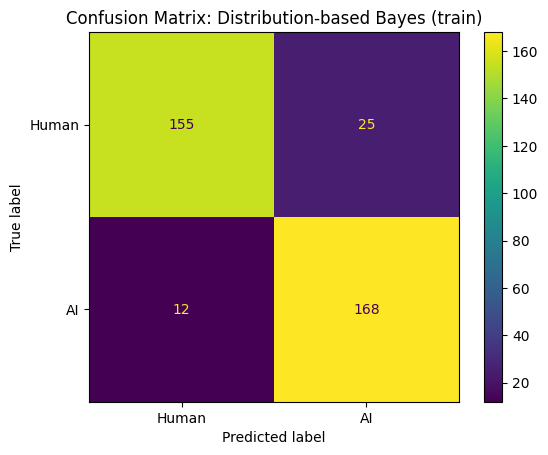

Average precision: 0.9606063584071791


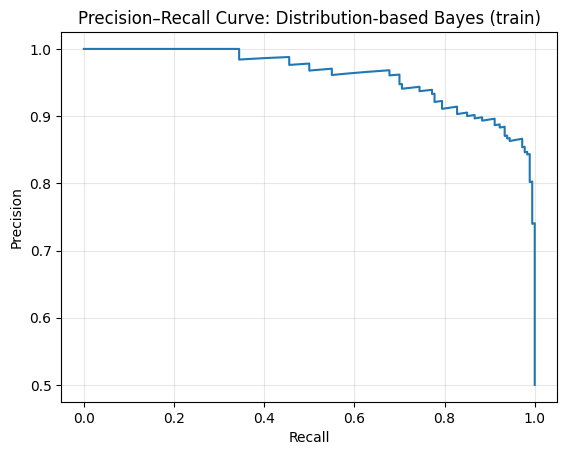


Gaussian Weighted Naive Bayes (train)
              precision    recall  f1-score   support

       Human       0.81      0.97      0.89       180
          AI       0.97      0.78      0.86       180

    accuracy                           0.88       360
   macro avg       0.89      0.88      0.87       360
weighted avg       0.89      0.88      0.87       360



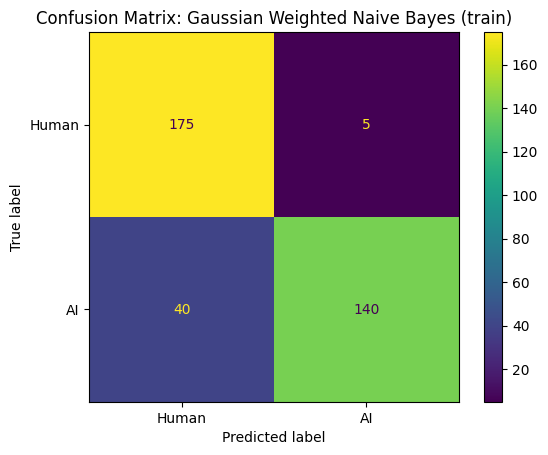

Average precision: 0.9778766392284846


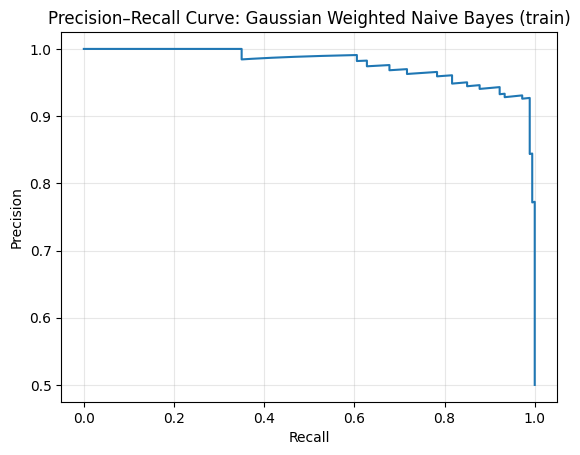


Logistic regression on raw features (train)
              precision    recall  f1-score   support

       Human       0.93      0.97      0.95       180
          AI       0.97      0.93      0.95       180

    accuracy                           0.95       360
   macro avg       0.95      0.95      0.95       360
weighted avg       0.95      0.95      0.95       360



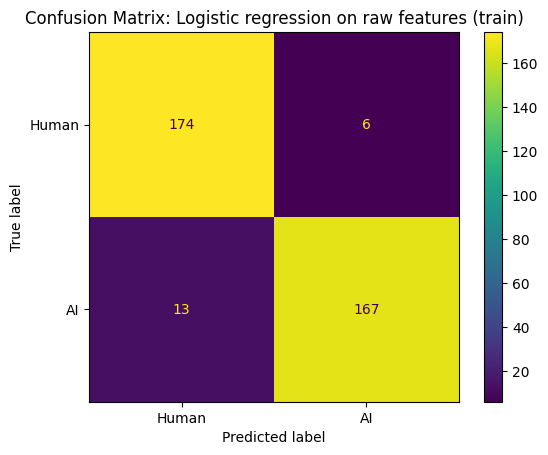

Average precision: 0.9940765789219476


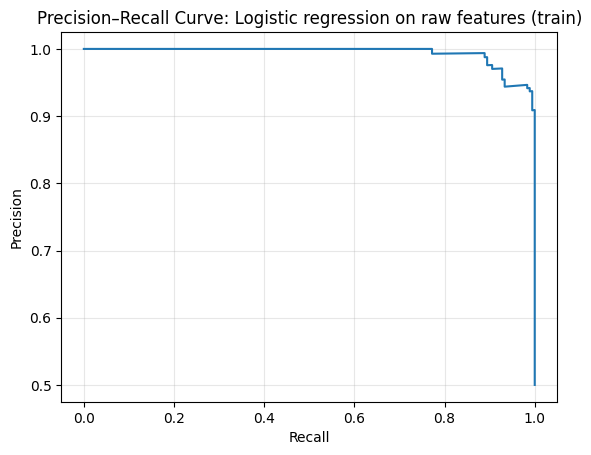


Logistic regression on log-likelihood evidence (train)
              precision    recall  f1-score   support

       Human       0.92      0.96      0.94       180
          AI       0.95      0.92      0.93       180

    accuracy                           0.94       360
   macro avg       0.94      0.94      0.94       360
weighted avg       0.94      0.94      0.94       360



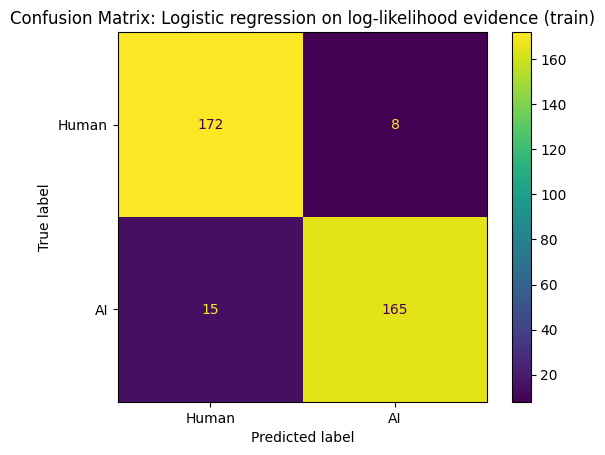

Average precision: 0.9866329222642927


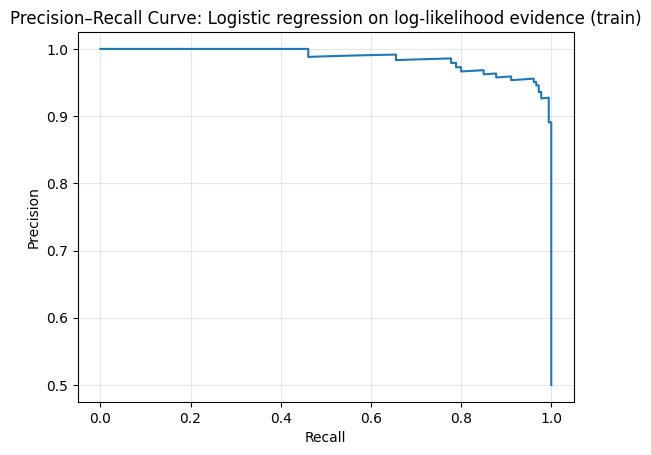


Train set comparison:
   split                                              model  accuracy  \
0  train                   Distribution-based Bayes (train)     0.897   
1  train              Gaussian Weighted Naive Bayes (train)     0.875   
2  train        Logistic regression on raw features (train)     0.947   
3  train  Logistic regression on log-likelihood evidence...     0.936   

   human_precision  human_recall  human_f1  ai_precision  ai_recall  ai_f1  \
0            0.928         0.861     0.893         0.870      0.933  0.901   
1            0.814         0.972     0.886         0.966      0.778  0.862   
2            0.930         0.967     0.948         0.965      0.928  0.946   
3            0.920         0.956     0.937         0.954      0.917  0.935   

   macro_f1  average_precision  
0     0.897              0.961  
1     0.874              0.978  
2     0.947              0.994  
3     0.936              0.987  


In [55]:
train_predictions = predict_all_models(train_df)
train_evaluations, train_comparison = evaluate_all_models(
    train_predictions,
    split_name="train",)


VALIDATION SET EVALUATION

Distribution-based Bayes (validation)
              precision    recall  f1-score   support

       Human       0.90      0.88      0.89        60
          AI       0.89      0.90      0.89        60

    accuracy                           0.89       120
   macro avg       0.89      0.89      0.89       120
weighted avg       0.89      0.89      0.89       120



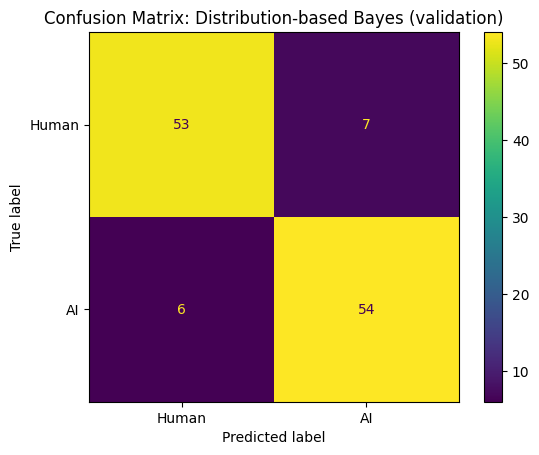

Average precision: 0.9562823224410452


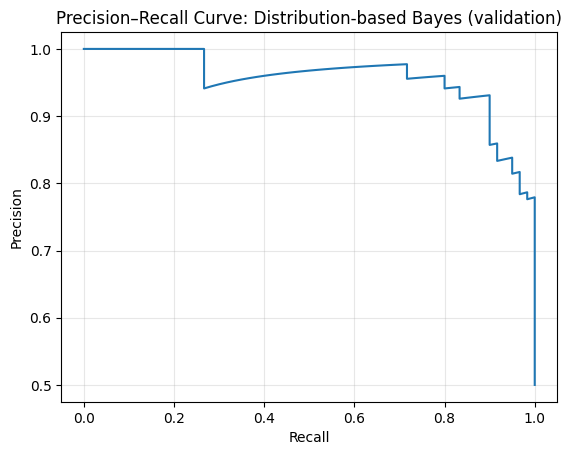


Gaussian Weighted Naive Bayes (validation)
              precision    recall  f1-score   support

       Human       0.78      0.98      0.87        60
          AI       0.98      0.72      0.83        60

    accuracy                           0.85       120
   macro avg       0.88      0.85      0.85       120
weighted avg       0.88      0.85      0.85       120



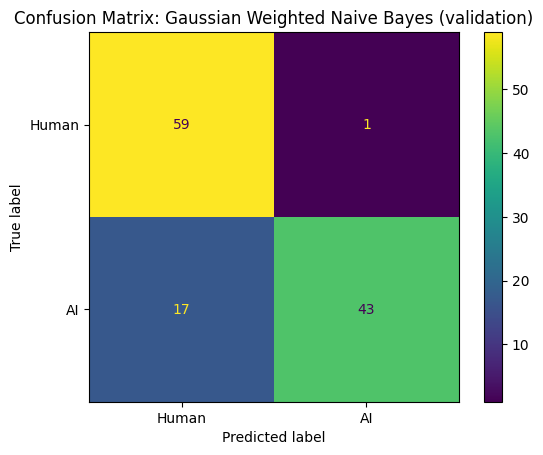

Average precision: 0.9678990316596832


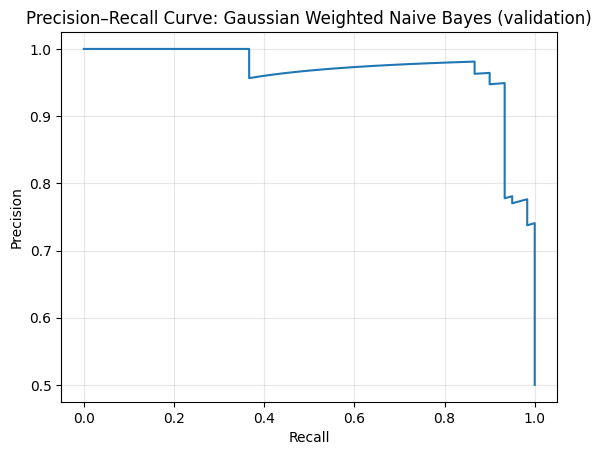


Logistic regression on raw features (validation)
              precision    recall  f1-score   support

       Human       0.87      0.97      0.91        60
          AI       0.96      0.85      0.90        60

    accuracy                           0.91       120
   macro avg       0.91      0.91      0.91       120
weighted avg       0.91      0.91      0.91       120



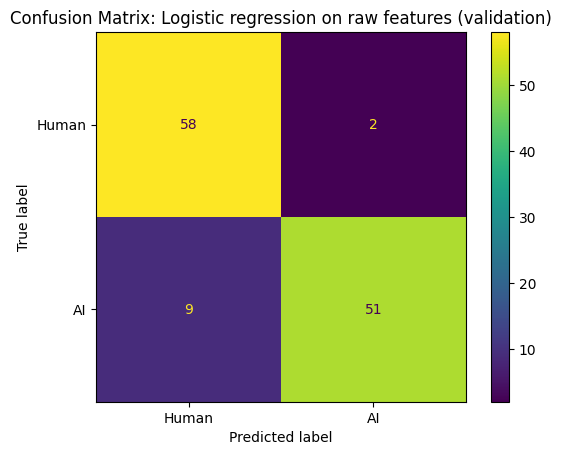

Average precision: 0.9766822004846869


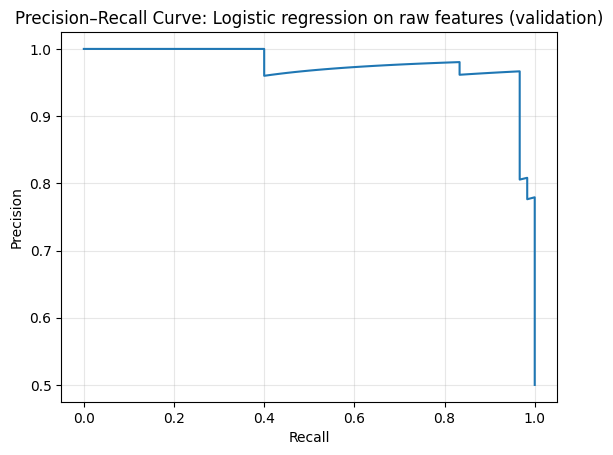


Logistic regression on log-likelihood evidence (validation)
              precision    recall  f1-score   support

       Human       0.87      0.98      0.92        60
          AI       0.98      0.85      0.91        60

    accuracy                           0.92       120
   macro avg       0.92      0.92      0.92       120
weighted avg       0.92      0.92      0.92       120



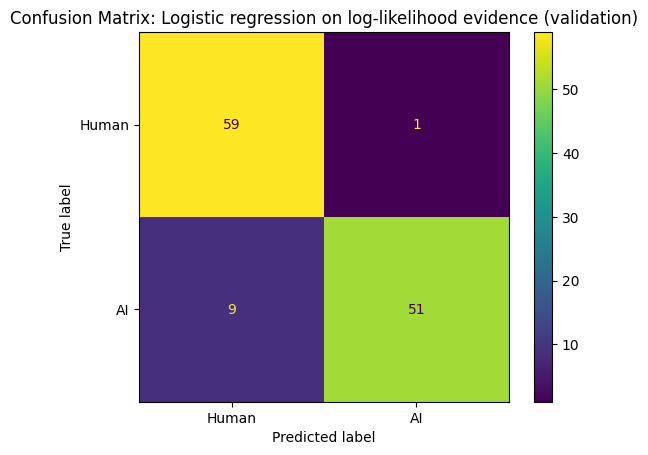

Average precision: 0.9706174084711002


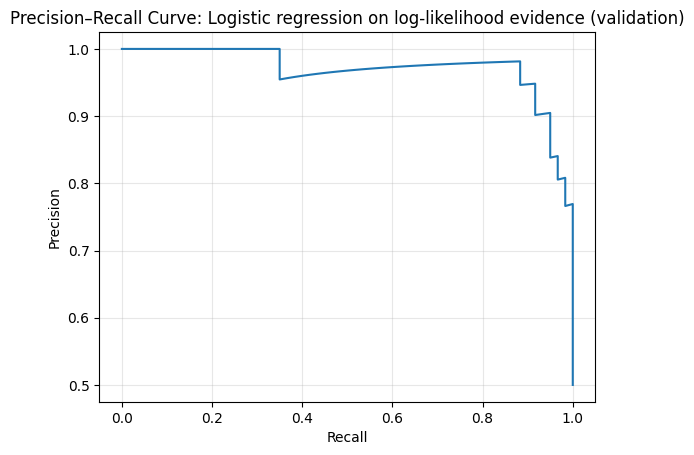


Validation set comparison:
        split                                              model  accuracy  \
0  validation              Distribution-based Bayes (validation)     0.892   
1  validation         Gaussian Weighted Naive Bayes (validation)     0.850   
2  validation   Logistic regression on raw features (validation)     0.908   
3  validation  Logistic regression on log-likelihood evidence...     0.917   

   human_precision  human_recall  human_f1  ai_precision  ai_recall  ai_f1  \
0            0.898         0.883     0.891         0.885      0.900  0.893   
1            0.776         0.983     0.868         0.977      0.717  0.827   
2            0.866         0.967     0.913         0.962      0.850  0.903   
3            0.868         0.983     0.922         0.981      0.850  0.911   

   macro_f1  average_precision  
0     0.892              0.956  
1     0.847              0.968  
2     0.908              0.977  
3     0.916              0.971  


In [56]:
validation_predictions = predict_all_models(val_df)
validation_evaluations, validation_comparison = evaluate_all_models(
    validation_predictions,
    split_name="validation",
)


TEST SET EVALUATION

Distribution-based Bayes (test)
              precision    recall  f1-score   support

       Human       0.95      0.93      0.94        60
          AI       0.93      0.95      0.94        60

    accuracy                           0.94       120
   macro avg       0.94      0.94      0.94       120
weighted avg       0.94      0.94      0.94       120



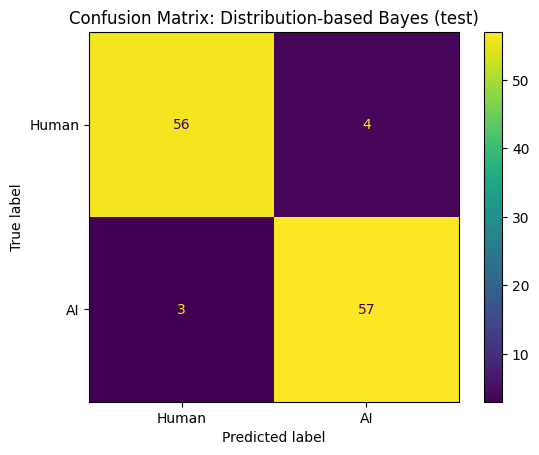

Average precision: 0.9793346706271094


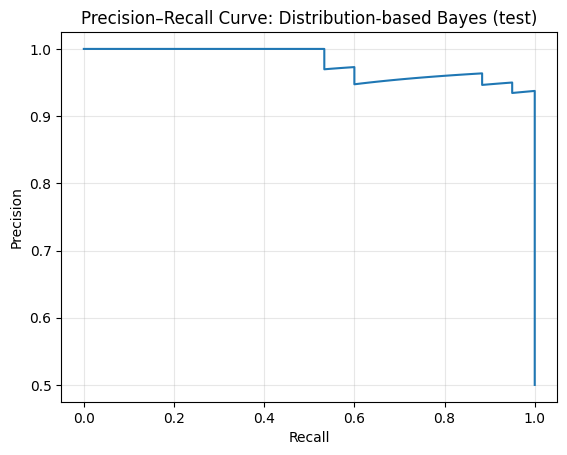


Gaussian Weighted Naive Bayes (test)
              precision    recall  f1-score   support

       Human       0.82      0.98      0.89        60
          AI       0.98      0.78      0.87        60

    accuracy                           0.88       120
   macro avg       0.90      0.88      0.88       120
weighted avg       0.90      0.88      0.88       120



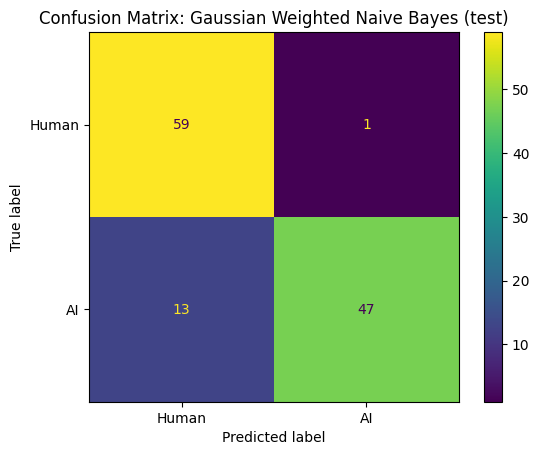

Average precision: 0.9924306425664399


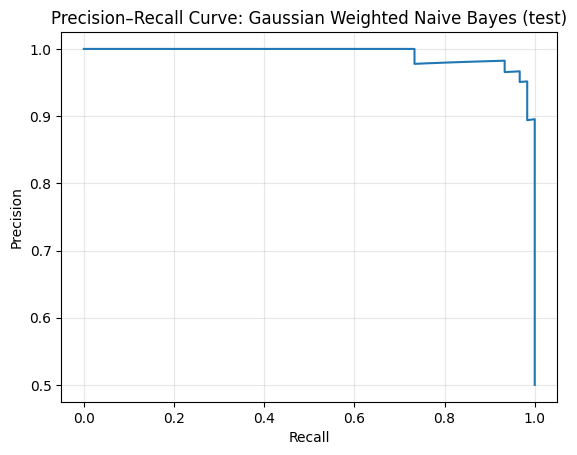


Logistic regression on raw features (test)
              precision    recall  f1-score   support

       Human       0.91      0.97      0.94        60
          AI       0.96      0.90      0.93        60

    accuracy                           0.93       120
   macro avg       0.94      0.93      0.93       120
weighted avg       0.94      0.93      0.93       120



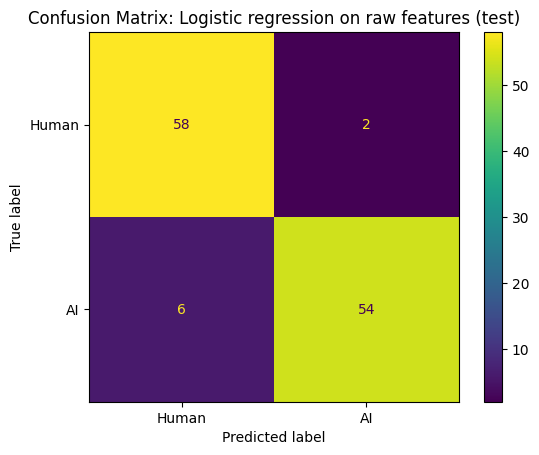

Average precision: 0.9927615062959612


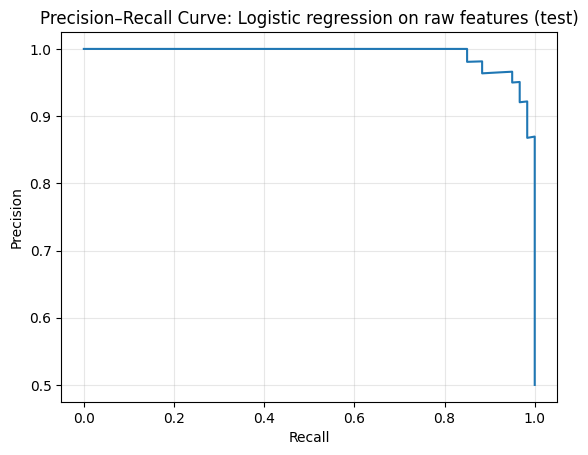


Logistic regression on log-likelihood evidence (test)
              precision    recall  f1-score   support

       Human       0.97      0.97      0.97        60
          AI       0.97      0.97      0.97        60

    accuracy                           0.97       120
   macro avg       0.97      0.97      0.97       120
weighted avg       0.97      0.97      0.97       120



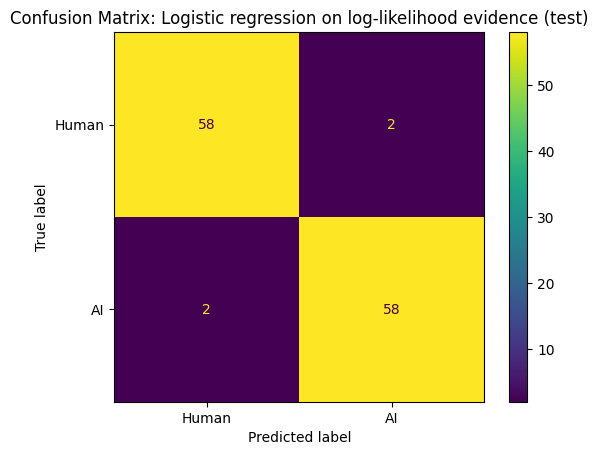

Average precision: 0.9905365439359235


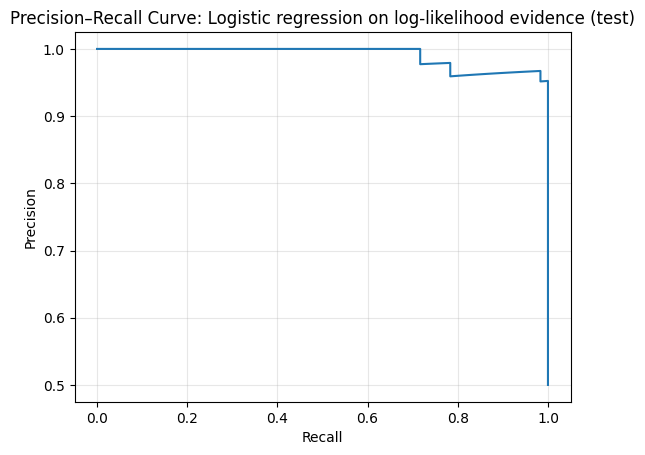


Test set comparison:
  split                                              model  accuracy  \
0  test                    Distribution-based Bayes (test)     0.942   
1  test               Gaussian Weighted Naive Bayes (test)     0.883   
2  test         Logistic regression on raw features (test)     0.933   
3  test  Logistic regression on log-likelihood evidence...     0.967   

   human_precision  human_recall  human_f1  ai_precision  ai_recall  ai_f1  \
0            0.949         0.933     0.941         0.934      0.950  0.942   
1            0.819         0.983     0.894         0.979      0.783  0.870   
2            0.906         0.967     0.935         0.964      0.900  0.931   
3            0.967         0.967     0.967         0.967      0.967  0.967   

   macro_f1  average_precision  
0     0.942              0.979  
1     0.882              0.992  
2     0.933              0.993  
3     0.967              0.991  


In [57]:
test_predictions = predict_all_models(test_df)
test_evaluations, test_comparison = evaluate_all_models(
    test_predictions,
    split_name="test",)

In [60]:
loglik_coef_table = statsmodels_logistic_summary_table(loglik_logistic_model)

print("\nLog-likelihood logistic regression coefficient table:")
print(loglik_coef_table.round(4))

loglik_coef_table.to_csv(
    "loglik_logistic_statsmodels_coefficients.csv",
    index=False
)


Log-likelihood logistic regression coefficient table:
                         feature    coef  p_value  coef_CI_lower  \
0                        Zipf_R2 -9.8614   0.0210       -18.2352   
1                      Zipf_RMSE  7.5225   0.0021         2.7397   
2                           Gini  7.1838   0.1846        -3.4276   
3                     Zipf_slope  4.7705   0.6001       -13.0650   
4                      Intercept -3.8608   0.0023        -6.3411   
5                    MAL_word_R2  3.6375   0.0710        -0.3119   
6       word_length_distribution  2.3227   0.0012         0.9211   
7                 Heaps_exponent -1.8097   0.3170        -5.3546   
8                             R1  1.3996   0.0526        -0.0158   
9                     Heaps_RMSE -1.3025   0.1903        -3.2520   
10       tree_depth_distribution  1.2087   0.4535        -1.9519   
11                             R  1.1843   0.5215        -2.4370   
12                         Hapax  1.0926   0.8885       -14.1

In [61]:
report_table = loglik_coef_table[
    loglik_coef_table["feature"] != "Intercept"
].copy()

report_table["significant_005"] = report_table["p_value"] < 0.05
report_table["significant_010"] = report_table["p_value"] < 0.10

report_table = report_table.sort_values("abs_coef", ascending=False)

presentation_table = report_table[
    [
        "feature",
        "coef",
        "p_value",
        "odds_ratio",
        "OR_CI_lower",
        "OR_CI_upper",
    ]
].head(8)

print(presentation_table.round(4))

presentation_table.round(4).to_csv(
    "presentation_loglik_logistic_top_coefficients.csv",
    index=False
)

                    feature    coef  p_value  odds_ratio  OR_CI_lower  \
0                   Zipf_R2 -9.8614   0.0210      0.0001       0.0000   
1                 Zipf_RMSE  7.5225   0.0021   1849.1291      15.4816   
2                      Gini  7.1838   0.1846   1317.9406       0.0325   
3                Zipf_slope  4.7705   0.6001    117.9759       0.0000   
5               MAL_word_R2  3.6375   0.0710     37.9968       0.7321   
6  word_length_distribution  2.3227   0.0012     10.2027       2.5120   
7            Heaps_exponent -1.8097   0.3170      0.1637       0.0047   
8                        R1  1.3996   0.0526      4.0536       0.9843   

    OR_CI_upper  
0  2.259000e-01  
1  2.208605e+05  
2  5.350545e+07  
3  6.570992e+09  
5  1.972135e+03  
6  4.143820e+01  
7  5.669600e+00  
8  1.669310e+01  


In [62]:
important_table = report_table[
    (report_table["p_value"] < 0.10)
].copy()

important_table = important_table[
    [
        "feature",
        "coef",
        "p_value",
        "odds_ratio",
        "OR_CI_lower",
        "OR_CI_upper",
    ]
].sort_values("p_value")

print(important_table.round(4))

important_table.round(4).to_csv(
    "presentation_loglik_logistic_significant_coefficients.csv",
    index=False
)

                    feature    coef  p_value  odds_ratio  OR_CI_lower  \
6  word_length_distribution  2.3227   0.0012     10.2027       2.5120   
1                 Zipf_RMSE  7.5225   0.0021   1849.1291      15.4816   
0                   Zipf_R2 -9.8614   0.0210      0.0001       0.0000   
8                        R1  1.3996   0.0526      4.0536       0.9843   
5               MAL_word_R2  3.6375   0.0710     37.9968       0.7321   

   OR_CI_upper  
6      41.4382  
1  220860.5250  
0       0.2259  
8      16.6931  
5    1972.1354  
